## Exploración y comprensión de los datos:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from PIL import Image

### Cargar el dataset proporcionado y realizar un análisis exploratorio de los datos

In [5]:
# Dataset principal de crímenes
df = pd.read_csv("Crimes_-_2025_20260312.csv")

# Dataset de Community Areas (nombres de las áreas)
community_areas = pd.read_csv('Boundaries_-_Community_Areas_20260329.csv', usecols=['AREA_NUMBE', 'COMMUNITY'])
community_areas = community_areas.rename(columns={'AREA_NUMBE': 'Community Area', 'COMMUNITY': 'Community Area Description'})
community_areas['Community Area'] = community_areas['Community Area'].astype(int)

# Dataset de códigos IUCR (descripción de delitos)
iucr_codes = pd.read_csv('Chicago_Police_Department_-_Illinois_Uniform_Crime_Reporting_(IUCR)_Codes_20260329.csv')
iucr_codes = iucr_codes.rename(columns={'PRIMARY DESCRIPTION': 'IUCR Primary', 'SECONDARY DESCRIPTION': 'IUCR Secondary', 'INDEX CODE': 'Index Code'})
iucr_codes['IUCR'] = iucr_codes['IUCR'].str.zfill(4)

# Dataset enriquecido: merge único con IUCR y Community Areas
df_chicago = df.merge(iucr_codes[['IUCR', 'IUCR Primary', 'IUCR Secondary', 'Index Code']], on='IUCR', how='left') \
               .merge(community_areas, on='Community Area', how='left')

# Validación: verificar que el merge no duplicó ni perdió filas
print(f"Dataset original:     {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Dataset enriquecido:  {df_chicago.shape[0]} filas, {df_chicago.shape[1]} columnas")
assert df.shape[0] == df_chicago.shape[0], "ERROR: el merge alteró la cantidad de filas"
print("Validación OK: misma cantidad de filas")
df_chicago

Dataset original:     236686 filas, 22 columnas
Dataset enriquecido:  236686 filas, 26 columnas
Validación OK: misma cantidad de filas


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,IUCR Primary,IUCR Secondary,Index Code,Community Area Description
0,14075483,JK105557,12/31/2025 11:58:00 PM,050XX S PAULINA ST,0560,ASSAULT,SIMPLE,RESIDENCE,False,False,...,1871343.0,2025,01/09/2026 03:40:47 PM,41.802549,-87.667246,POINT (-87.667246428 41.802549018),ASSAULT,SIMPLE,N,NEW CITY
1,14070833,JK100050,12/31/2025 11:55:00 PM,053XX W WASHINGTON BLVD,0930,MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,APARTMENT,False,True,...,1900235.0,2025,01/08/2026 03:46:48 PM,41.882329,-87.758411,POINT (-87.758411303 41.882328854),MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,I,AUSTIN
2,14070745,JK100011,12/31/2025 11:54:00 PM,100XX W OHARE ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,AIRCRAFT,False,False,...,1934241.0,2025,01/08/2026 03:46:48 PM,41.976290,-87.905227,POINT (-87.905227221 41.976290414),PUBLIC PEACE VIOLATION,OTHER VIOLATION,N,OHARE
3,14070845,JK100006,12/31/2025 11:54:00 PM,013XX W LAKE ST,0454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",RESTAURANT,True,False,...,1901555.0,2025,01/08/2026 03:46:48 PM,41.885427,-87.661759,POINT (-87.661759042 41.885426714),BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",N,NEAR WEST SIDE
4,14070799,JK100014,12/31/2025 11:54:00 PM,100XX W OHARE ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,AIRCRAFT,False,False,...,1934241.0,2025,01/08/2026 03:46:48 PM,41.976290,-87.905227,POINT (-87.905227221 41.976290414),PUBLIC PEACE VIOLATION,OTHER VIOLATION,N,OHARE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236681,14011867,JJ468702,01/01/2025 12:00:00 AM,122XX S THROOP ST,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,...,1823639.0,2025,11/02/2025 03:41:09 PM,41.671556,-87.653881,POINT (-87.653880899 41.671556077),CRIMINAL DAMAGE,TO PROPERTY,N,WEST PULLMAN
236682,13723166,JJ118245,01/01/2025 12:00:00 AM,035XX N WILTON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,1923754.0,2025,11/02/2025 03:41:09 PM,41.946295,-87.653085,POINT (-87.653085108 41.946294768),CRIMINAL DAMAGE,TO VEHICLE,N,LAKE VIEW
236683,13762064,JJ165443,01/01/2025 12:00:00 AM,026XX W HIRSCH ST,1365,CRIMINAL TRESPASS,TO RESIDENCE,RESIDENCE,False,False,...,1909206.0,2025,11/02/2025 03:41:09 PM,41.906605,-87.693663,POINT (-87.693662846 41.906605031),CRIMINAL TRESPASS,TO RESIDENCE,N,WEST TOWN
236684,13924498,JJ362854,01/01/2025 12:00:00 AM,028XX N KILBOURN AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,SCHOOL - PUBLIC GROUNDS,False,False,...,1918497.0,2025,11/02/2025 03:41:09 PM,41.932347,-87.739275,POINT (-87.739274504 41.932346705),CRIMINAL DAMAGE,TO PROPERTY,N,HERMOSA


### Describir las características principales del dataset, incluyendo el número de observaciones, número de variables y tipos de datos.

Tipos de variables:
* Localización: latitude, longitude, community area, district, location.
* Tipos de crímenes: IUCR, FBI code, domestic, arrest.
* Claves/ID: ID, case number.

Descripción general
* Filas: 236686
* Columnas: 22
* Columnas ID: 2
* Año: 2025

Variables categóricas
* Date
* Arrest
* Domestic
* FBI Code
* District
* Ward
* Description
* Location

Variables numéricas
* Date
* Latitude
* Longitude

In [6]:
df.shape

(236686, 22)

In [7]:
df.dtypes

ID                        int64
Case Number              object
Date                     object
Block                    object
IUCR                     object
Primary Type             object
Description              object
Location Description     object
Arrest                     bool
Domestic                   bool
Beat                      int64
District                  int64
Ward                    float64
Community Area          float64
FBI Code                 object
X Coordinate            float64
Y Coordinate            float64
Year                      int64
Updated On               object
Latitude                float64
Longitude               float64
Location                 object
dtype: object

In [8]:
df.describe()

,ID,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude
count,2.366860e+05,236686.000000,236686.000000,236685.000000,236683.000000,2.365950e+05,2.365950e+05,236686.0,236595.000000,236595.000000
mean,1.386830e+07,1144.936304,11.219286,23.082823,36.344262,1.165672e+06,1.887167e+06,2025.0,41.845959,-87.667526
std,5.963141e+05,708.312969,7.078172,13.936868,21.540261,1.626736e+04,3.143058e+04,0.0,0.086432,0.059234
min,2.854500e+04,111.000000,1.000000,1.000000,1.000000,1.093568e+06,1.813897e+06,2025.0,41.644590,-87.931147
25%,1.380236e+07,531.000000,5.000000,10.000000,22.000000,1.154292e+06,1.860174e+06,2025.0,41.771733,-87.708836
50%,1.389328e+07,1032.000000,10.000000,23.000000,32.000000,1.167660e+06,1.893594e+06,2025.0,41.863664,-87.660046
75%,1.398376e+07,1731.000000,17.000000,34.000000,53.000000,1.176868e+06,1.909943e+06,2025.0,41.908493,-87.626358
max,1.413348e+07,2535.000000,31.000000,50.000000,77.000000,1.205119e+06,1.951517e+06,2025.0,42.022559,-87.524529


In [9]:
# Asimetría y curtosis de variables numéricas
# Forma de la distribución de variables numéricas:
# Asimetría: 0 = simétrica, >0 = cola derecha, <0 = cola izquierda
# Curtosis: 0 = normal, >0 = colas pesadas (leptocúrtica), <0 = colas livianas (platicúrtica)
cols_num = df.select_dtypes(include=[np.number]).columns
asimetria = df[cols_num].skew()
curtosis = df[cols_num].kurt()

stats_forma = pd.DataFrame({'Asimetría (Skewness)': asimetria, 'Curtosis (Kurtosis)': curtosis})
stats_forma

,Asimetría (Skewness),Curtosis (Kurtosis)
ID,-22.443119,517.972612
Beat,0.353446,-0.976902
District,0.356177,-0.972386
Ward,0.180542,-1.098810
Community Area,0.234650,-1.021139
X Coordinate,-0.437130,0.404430
Y Coordinate,-0.104976,-0.929221
Year,0.000000,0.000000
Latitude,-0.105620,-0.930999
Longitude,-0.451173,0.417494


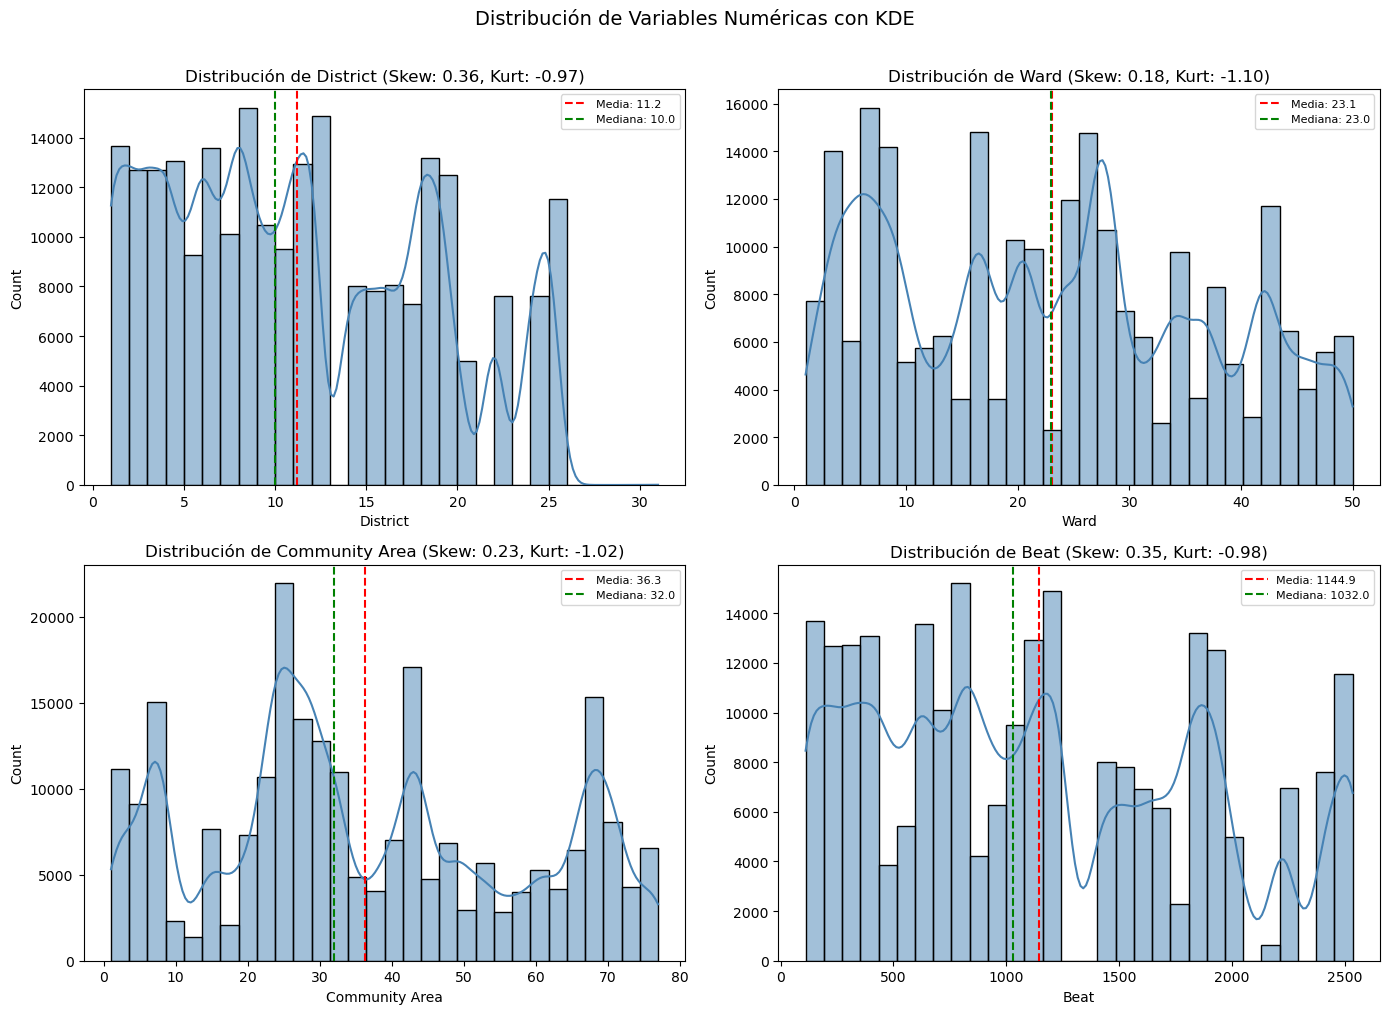

In [10]:
# Histogramas con KDE para variables numéricas relevantes
vars_analisis = ['District', 'Ward', 'Community Area', 'Beat']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), vars_analisis):
    data = df[col].dropna()
    sns.histplot(data, bins=30, kde=True, ax=ax, color='steelblue')
    ax.axvline(data.mean(), color='red', linestyle='--', lw=1.5, label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color='green', linestyle='--', lw=1.5, label=f'Mediana: {data.median():.1f}')
    ax.set_title(f'Distribución de {col} (Skew: {data.skew():.2f}, Kurt: {data.kurt():.2f})')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Variables Numéricas con KDE', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Identificar patrones generales y distribuciones.

#### Distribución de Arrestos y Crímenes Domésticos
Se analiza la proporción de arrestos y crímenes domésticos para identificar desbalances en las variables categóricas binarias del dataset.

In [11]:
# Contar la cantidad de arrestos con porcentajes
arrestos = df_chicago['Arrest'].value_counts()
porcentajes = df_chicago['Arrest'].value_counts(normalize=True) * 100
pd.DataFrame({'Cantidad': arrestos, 'Porcentaje (%)': porcentajes.round(2)})

,Cantidad,Porcentaje (%)
Arrest,,
False,198898,84.03
True,37788,15.97


In [12]:
# Distribución de Crímenes Domésticos
# En Chicago, el crimen doméstico es cualquier abuso físico, acoso, intimidación, interferencia con la libertad personal o 
# privación voluntaria entre "miembros de la familia o del hogar", definido por la Ley de Violencia Doméstica de Illinois (IDVA). 
# Incluye violencia entre parejas íntimas, cónyuges, ex cónyuges, personas que comparten un hogar, o tienen hijos en común.
# https://www.womenslaw.org/es/leyes/il/ordenes-de-restriccion/ordenes-de-proteccion/informacion-basica/cual-es-la-definicion-legal

domestic_counts = df_chicago['Domestic'].value_counts()
domestic_pct = df_chicago['Domestic'].value_counts(normalize=True) * 100
print("Distribución de Crímenes Domésticos:")
for val, count in domestic_counts.items():
    print(f"  {val}: {count:,} ({domestic_pct[val]:.1f}%)")

Distribución de Crímenes Domésticos:
  False: 191,592 (80.9%)
  True: 45,094 (19.1%)


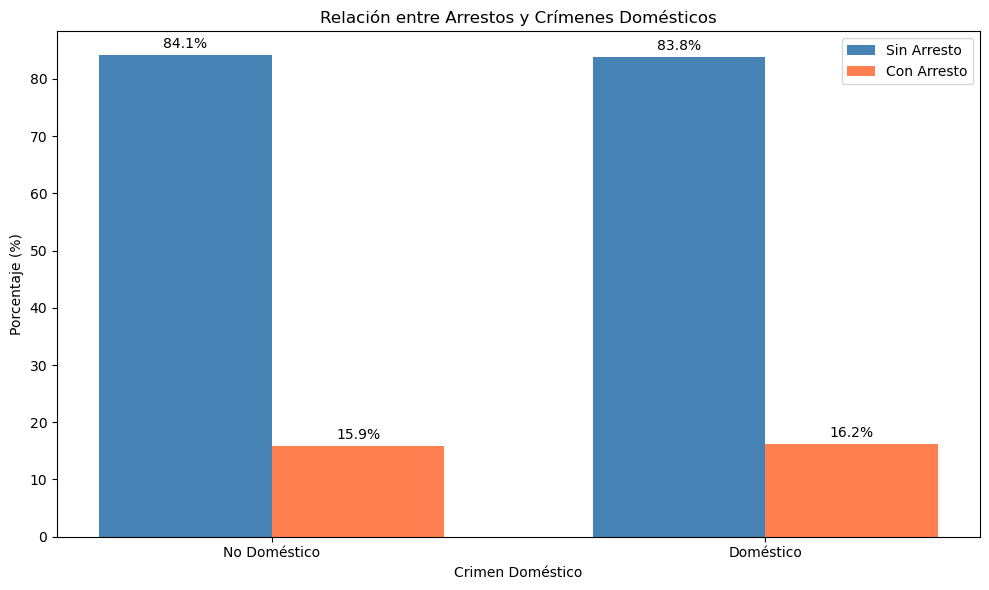

In [13]:
# Relación entre Arrestos y Crímenes Domésticos
cross_tab = pd.crosstab(df_chicago['Domestic'], df_chicago['Arrest'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(cross_tab.index))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], cross_tab[False], width, label='Sin Arresto', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], cross_tab[True], width, label='Con Arresto', color='coral')

ax.set_xlabel('Crimen Doméstico')
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Relación entre Arrestos y Crímenes Domésticos')
ax.set_xticks(x)
ax.set_xticklabels(['No Doméstico', 'Doméstico'])
ax.legend()

# Agregar etiquetas de porcentaje
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()

<Axes: xlabel='Arrest', ylabel='Domestic'>

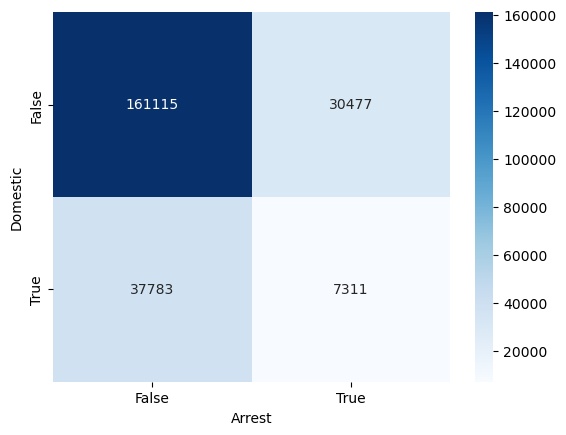

In [46]:
ct = pd.crosstab(df_chicago['Domestic'], df_chicago['Arrest'])

sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')

#### Tipos de crímenes más frecuentes
Se identifican los tipos de crímenes con mayor incidencia y se analiza la tasa de arrestos por código IUCR para detectar qué delitos tienen mayor efectividad policial.

Se utiliza el dataset de [códigos IUCR del Chicago Police Department](https://data.cityofchicago.org/Public-Safety/Chicago-Police-Department-Illinois-Uniform-Crime-R/c7ck-438e/about_data) para enriquecer el análisis con las descripciones oficiales y la clasificación **Index Code**:
- **"I" (Index Crime)**: delitos graves usados por el FBI como indicador de criminalidad (homicidio, robo, agresión agravada, hurto, robo de vehículo, etc.).
- **"N" (Non-Index Crime)**: delitos menores no incluidos en el índice principal (vandalismo, fraude, posesión de drogas, alteración del orden público, etc.).

In [14]:
# Top 10 tipos de crímenes más frecuentes (Primary Type)
top_crimes = df_chicago['Primary Type'].value_counts().head(10)
print("Top 10 tipos de crímenes más frecuentes:")
for crime, count in top_crimes.items():
    print(f"  {crime}: {count:,}")

Top 10 tipos de crímenes más frecuentes:
  THEFT: 55,047
  BATTERY: 42,542
  CRIMINAL DAMAGE: 26,207
  ASSAULT: 21,561
  MOTOR VEHICLE THEFT: 17,232
  OTHER OFFENSE: 16,745
  DECEPTIVE PRACTICE: 14,770
  BURGLARY: 9,710
  NARCOTICS: 7,417
  ROBBERY: 5,819


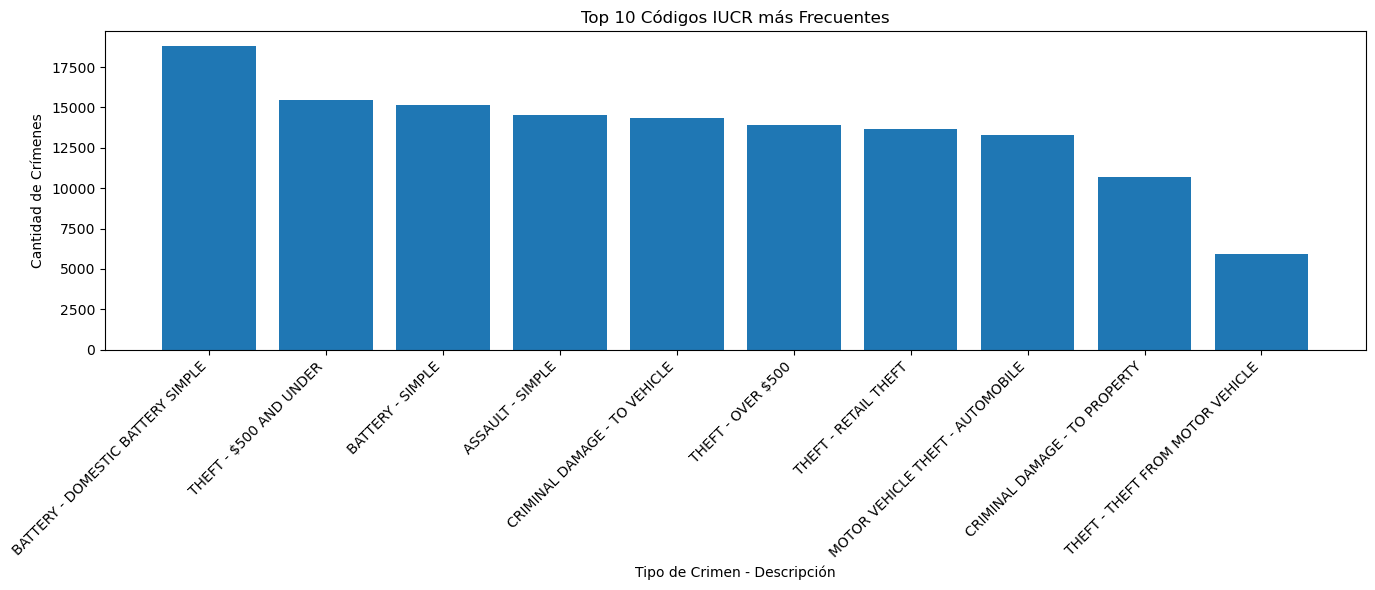

In [15]:
# Histograma de los códigos IUCR más frecuentes
plt.figure(figsize=(14, 6))
iucr_counts = df_chicago['IUCR'].value_counts().head(10)

# Crear etiquetas con Primary Type - Description
etiquetas = []
for iucr in iucr_counts.index:
    info = df_chicago[df_chicago['IUCR'] == iucr][['Primary Type', 'Description']].iloc[0]
    etiquetas.append(f"{info['Primary Type']} - {info['Description']}")

plt.bar(range(len(iucr_counts)), iucr_counts.values)
plt.xticks(range(len(iucr_counts)), etiquetas, rotation=45, ha='right')
plt.title('Top 10 Códigos IUCR más Frecuentes')
plt.xlabel('Tipo de Crimen - Descripción')
plt.ylabel('Cantidad de Crímenes')
plt.tight_layout()
plt.show()

C:\Users\aye_c\AppData\Local\Temp\ipykernel_18980\3285499609.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


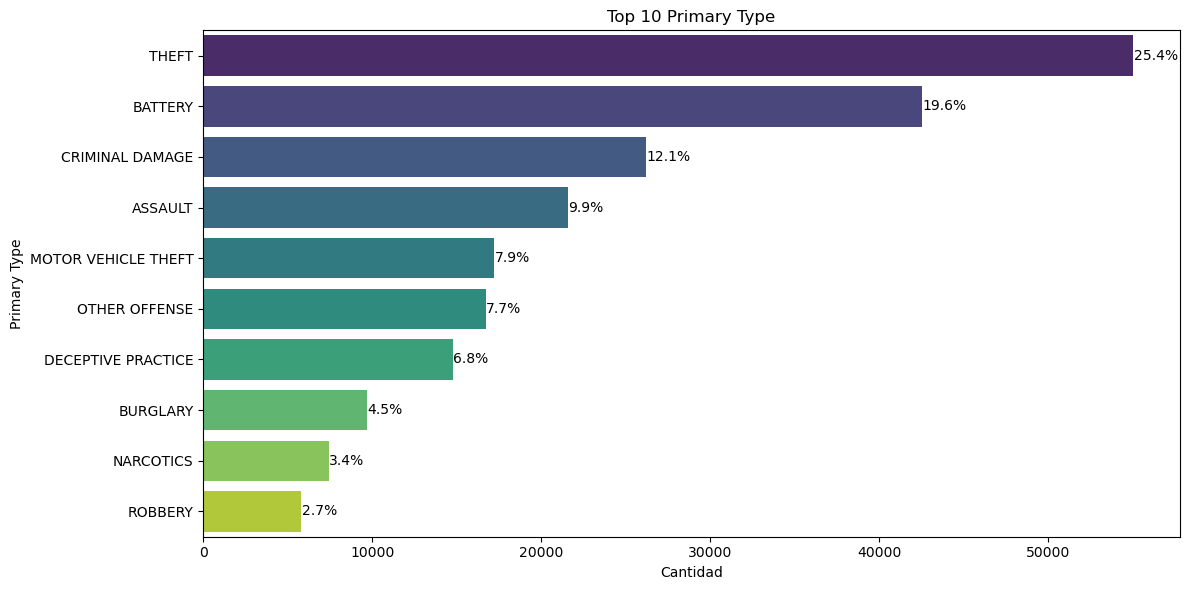

In [16]:
top_n = 10
top = df_chicago['Primary Type'].value_counts().nlargest(top_n).index

df_top = df_chicago[df_chicago['Primary Type'].isin(top)]

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df_top,
    y='Primary Type',
    order=top,
    palette='viridis'
)

# Porcentajes
total = len(df_top)
for i, p in enumerate(ax.patches):
    value = p.get_width()
    ax.text(value + 5, i, f"{value/total*100:.1f}%", va='center')

plt.title(f'Top {top_n} Primary Type')
plt.xlabel('Cantidad')
plt.ylabel('Primary Type')

plt.tight_layout()
plt.show()

* El crimen de battery (agresión física o lesiones) es el contacto físico intencional, ilícito y no consentido con otra persona que resulta en daño o es ofensivo. A diferencia del asalto (assault), que es la amenaza, la battery implica el contacto físico directo o indirecto (como usar un objeto o arma). 
* El criminal assault (agresión o asalto penal) es un delito que implica un acto intencional que causa en otra persona el temor razonable de sufrir un daño físico o contacto ofensivo inminente. No siempre requiere contacto físico real (lesiones), sino la amenaza creíble de violencia, diferenciándose de la "agresión física" (battery), que es el contacto físico en sí.
* El criminal damage (delito de daños) es un acto criminal que consiste en destruir, dañar o desfigurar intencionalmente o por imprudencia la propiedad ajena sin justificación legal. Puede clasificarse como un delito grave (felonía) si el valor del daño es alto o involucra servicios públicos esenciales.
* El crimen de Deceptive Practice (práctica engañosa) es una categoría amplia de actividad delictiva que implica engañar, estafar o inducir a error a sabiendas e intencionalmente a otra persona, empresa o entidad, generalmente para obtener un beneficio personal, financiero o de propiedad de forma ilícita.
* El burglary (robo con allanamiento de morada o fuerza en las cosas) es un delito penal anglosajón que consiste en entrar ilegalmente en un edificio, vivienda o vehículo cerrado con la intención de cometer un delito en su interior, generalmente robo o un crimen grave. No requiere violencia física contra personas. 
* El delito de robbery (atraco o robo con violencia) es la sustracción ilegal de propiedad ajena utilizando fuerza, amenazas o intimidación directa sobre la víctima. A diferencia del hurto (theft) o allanamiento (burglary), el robbery es considerado un delito violento contra la persona, a menudo castigado con penas severas. 

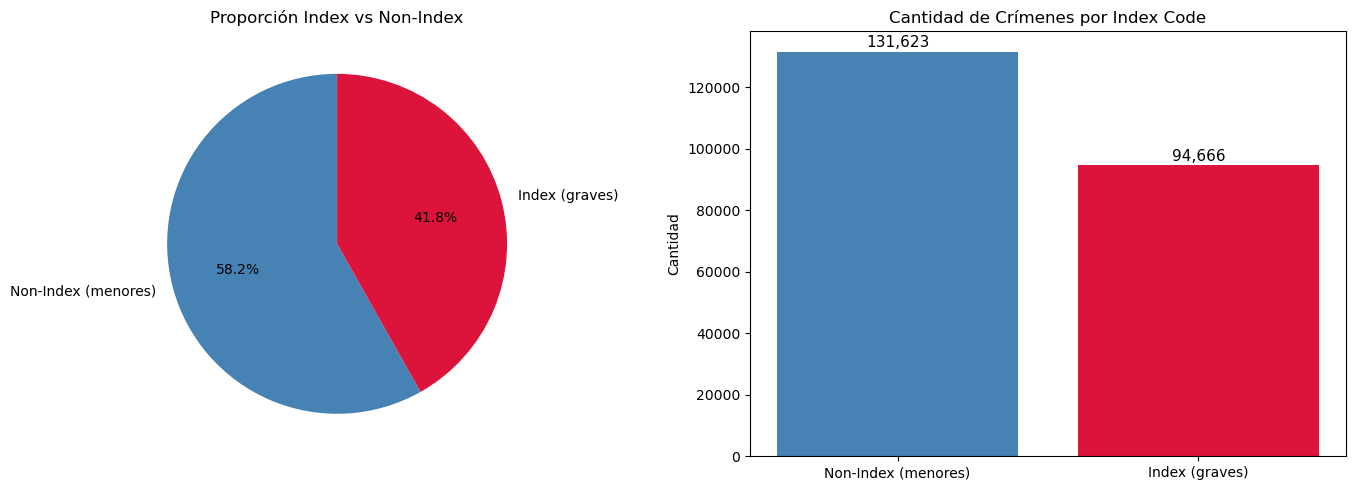

In [17]:
# Proporción de delitos índice vs no índice (gráfico simple)
index_pct = df_chicago['Index Code'].value_counts(normalize=True) * 100
index_counts = df_chicago['Index Code'].value_counts()

labels = ['Non-Index (menores)', 'Index (graves)']
sizes = [index_pct.get('N', 0), index_pct.get('I', 0)]
counts = [index_counts.get('N', 0), index_counts.get('I', 0)]
colors = ['steelblue', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title('Proporción Index vs Non-Index')

# Bar chart con cantidades
bars = axes[1].bar(labels, counts, color=colors)
axes[1].set_title('Cantidad de Crímenes por Index Code')
axes[1].set_ylabel('Cantidad')
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'{count:,}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

Clasificación de crímenes según Index Code (FBI):
  Index ('I' - delitos graves): 94,666 (41.8%)
  Non-Index ('N' - delitos menores): 131,623 (58.2%)


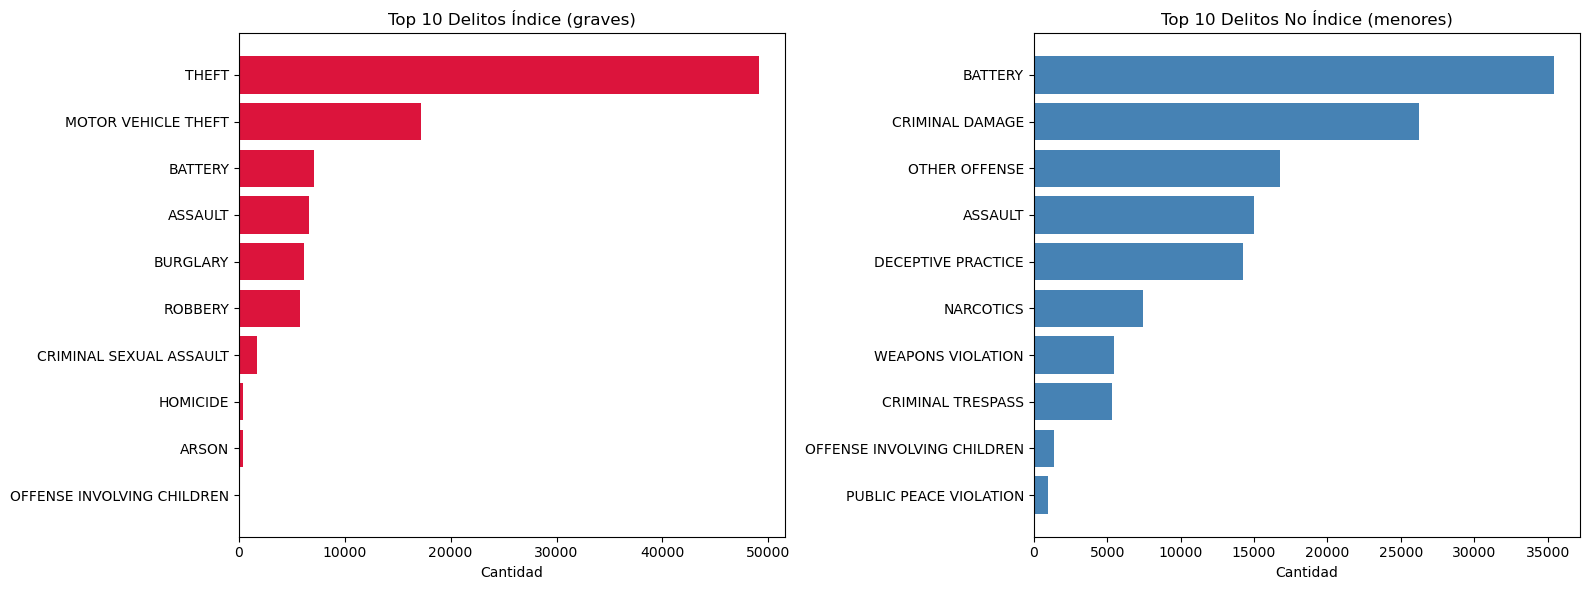

In [18]:
# Proporción de delitos índice vs no índice
index_counts = df_chicago['Index Code'].value_counts()
index_pct = df_chicago['Index Code'].value_counts(normalize=True) * 100

print("Clasificación de crímenes según Index Code (FBI):")
print(f"  Index ('I' - delitos graves): {index_counts.get('I', 0):,} ({index_pct.get('I', 0):.1f}%)")
print(f"  Non-Index ('N' - delitos menores): {index_counts.get('N', 0):,} ({index_pct.get('N', 0):.1f}%)")

# Top 10 crímenes índice vs no índice
top_index = df_chicago[df_chicago['Index Code'] == 'I']['Primary Type'].value_counts().head(10)
top_non_index = df_chicago[df_chicago['Index Code'] == 'N']['Primary Type'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_index.index[::-1], top_index.values[::-1], color='crimson')
axes[0].set_title('Top 10 Delitos Índice (graves)')
axes[0].set_xlabel('Cantidad')

axes[1].barh(top_non_index.index[::-1], top_non_index.values[::-1], color='steelblue')
axes[1].set_title('Top 10 Delitos No Índice (menores)')
axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

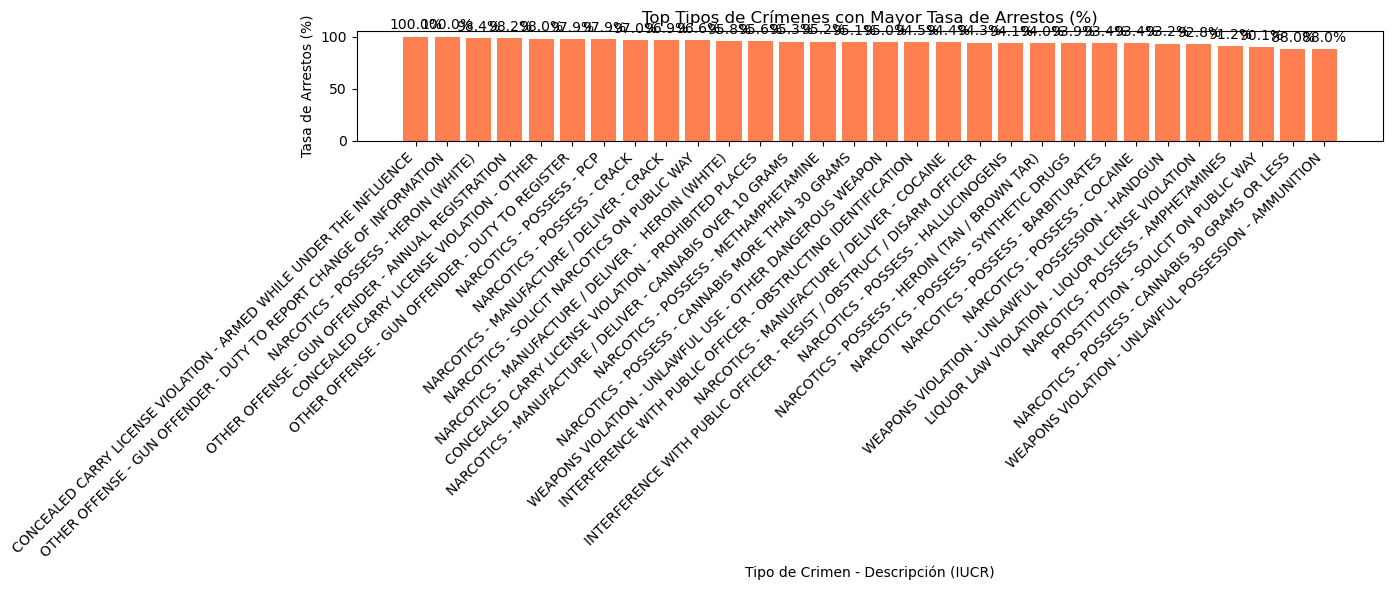

In [19]:
# Top tipos de crímenes con mayor tasa de arrestos (por código IUCR)
iucr_total = df_chicago.groupby('IUCR').size()
iucr_arrestos = df_chicago[df_chicago['Arrest'] == True].groupby('IUCR').size()
tasa_arresto = (iucr_arrestos / iucr_total * 100).dropna()

# Filtrar solo IUCR con al menos 50 casos para significancia estadística
iucr_significativos = iucr_total[iucr_total >= 50].index
tasa_arresto_filtrada = tasa_arresto[tasa_arresto.index.isin(iucr_significativos)]
top_tasa_arresto = tasa_arresto_filtrada.sort_values(ascending=False).head(30)

# Etiquetas usando las columnas enriquecidas de df_chicago
etiquetas_arrest = []
for iucr in top_tasa_arresto.index:
    row = df_chicago[df_chicago['IUCR'] == iucr].iloc[0]
    etiquetas_arrest.append(f"{row['IUCR Primary']} - {row['IUCR Secondary']}")

plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(top_tasa_arresto)), top_tasa_arresto.values, color='coral')
plt.xticks(range(len(top_tasa_arresto)), etiquetas_arrest, rotation=45, ha='right')
plt.title('Top Tipos de Crímenes con Mayor Tasa de Arrestos (%)')
plt.xlabel('Tipo de Crimen - Descripción (IUCR)')
plt.ylabel('Tasa de Arrestos (%)')

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()

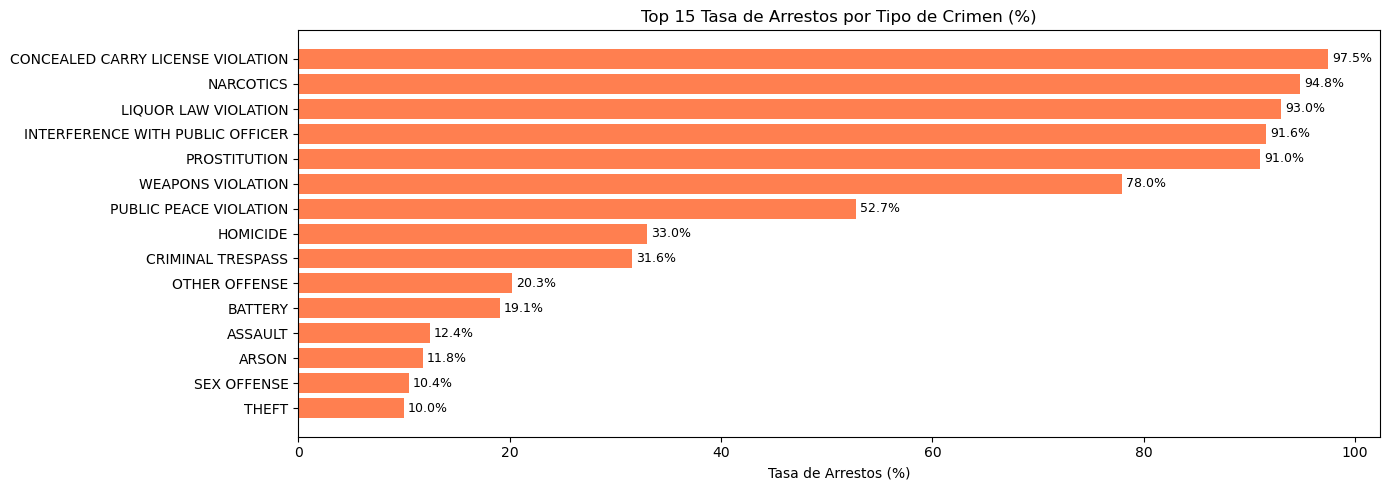

In [20]:
# Top 15 tasa de arrestos por tipo de crimen (IUCR Primary)
tipo_total = df_chicago.groupby('IUCR Primary').size()
tipo_arrestos = df_chicago[df_chicago['Arrest'] == True].groupby('IUCR Primary').size()
tasa = (tipo_arrestos / tipo_total * 100).dropna()

# Filtrar tipos con al menos 50 casos
sig = tipo_total[tipo_total >= 50].index
tasa = tasa[tasa.index.isin(sig)].sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 5))
bars = plt.barh(tasa.index[::-1], tasa.values[::-1], color='coral')
plt.title('Top 15 Tasa de Arrestos por Tipo de Crimen (%)')
plt.xlabel('Tasa de Arrestos (%)')

for bar in bars:
    width = bar.get_width()
    plt.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(3, 0), textcoords="offset points", ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

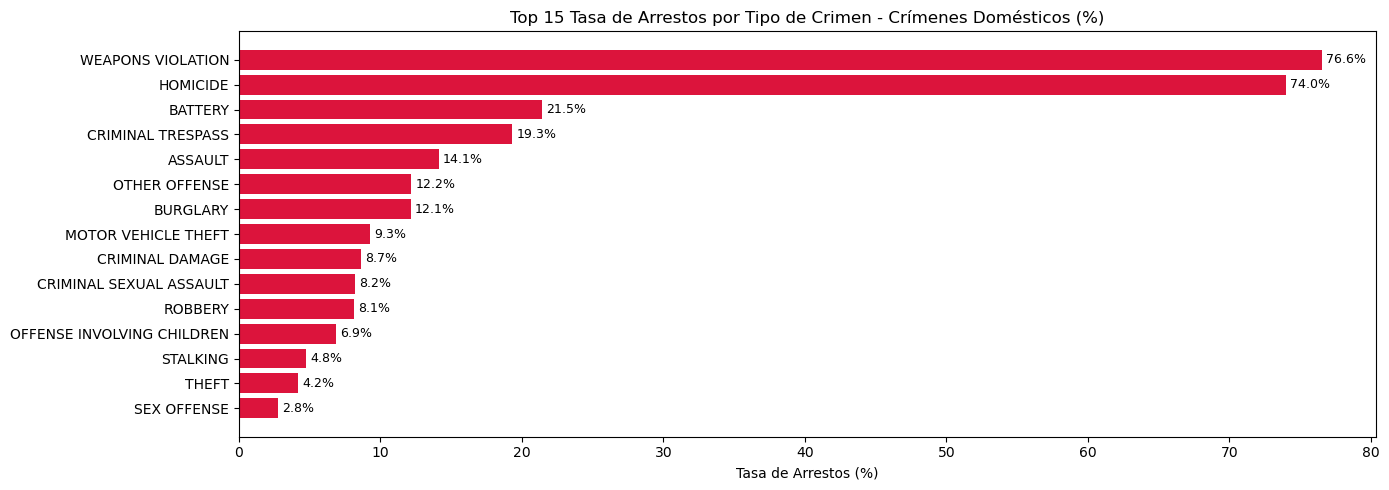

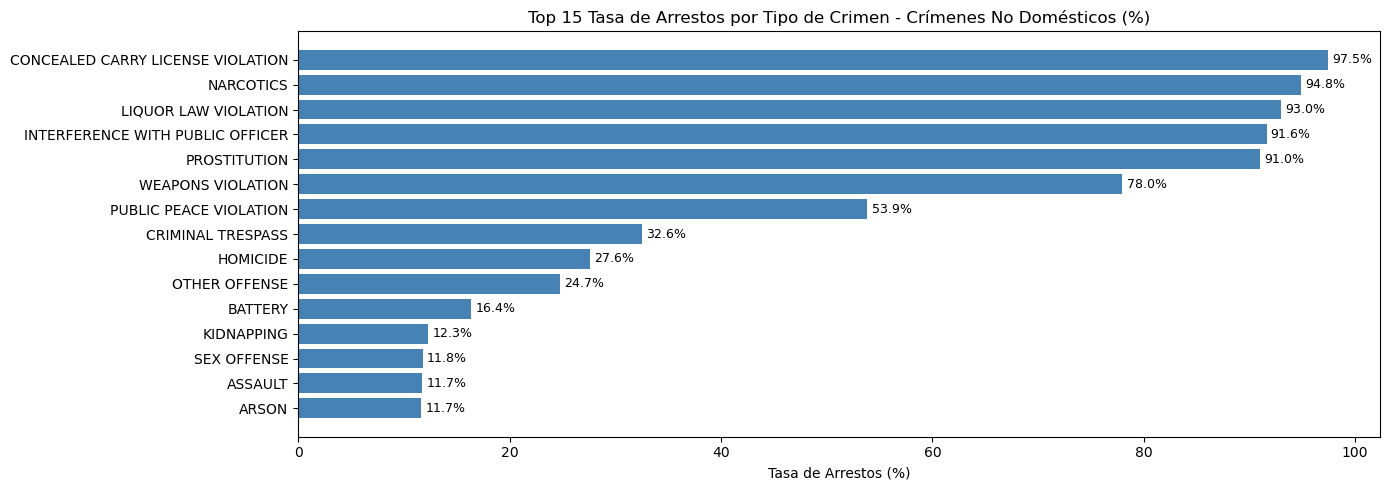

In [21]:
# Tasa de arrestos por tipo de crimen: Doméstico vs No Doméstico (por IUCR Primary)
for domestico, titulo, color in [(True, 'Crímenes Domésticos', 'crimson'), (False, 'Crímenes No Domésticos', 'steelblue')]:
    subset = df_chicago[df_chicago['Domestic'] == domestico]
    tipo_total = subset.groupby('IUCR Primary').size()
    tipo_arrestos = subset[subset['Arrest'] == True].groupby('IUCR Primary').size()
    tasa = (tipo_arrestos / tipo_total * 100).dropna()
    
    # Filtrar tipos con al menos 50 casos
    sig = tipo_total[tipo_total >= 50].index
    tasa = tasa[tasa.index.isin(sig)].sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(14, 5))
    bars = plt.barh(tasa.index[::-1], tasa.values[::-1], color=color)
    plt.title(f'Top 15 Tasa de Arrestos por Tipo de Crimen - {titulo} (%)')
    plt.xlabel('Tasa de Arrestos (%)')
    
    for bar in bars:
        width = bar.get_width()
        plt.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height()/2),
                    xytext=(3, 0), textcoords="offset points", ha='left', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

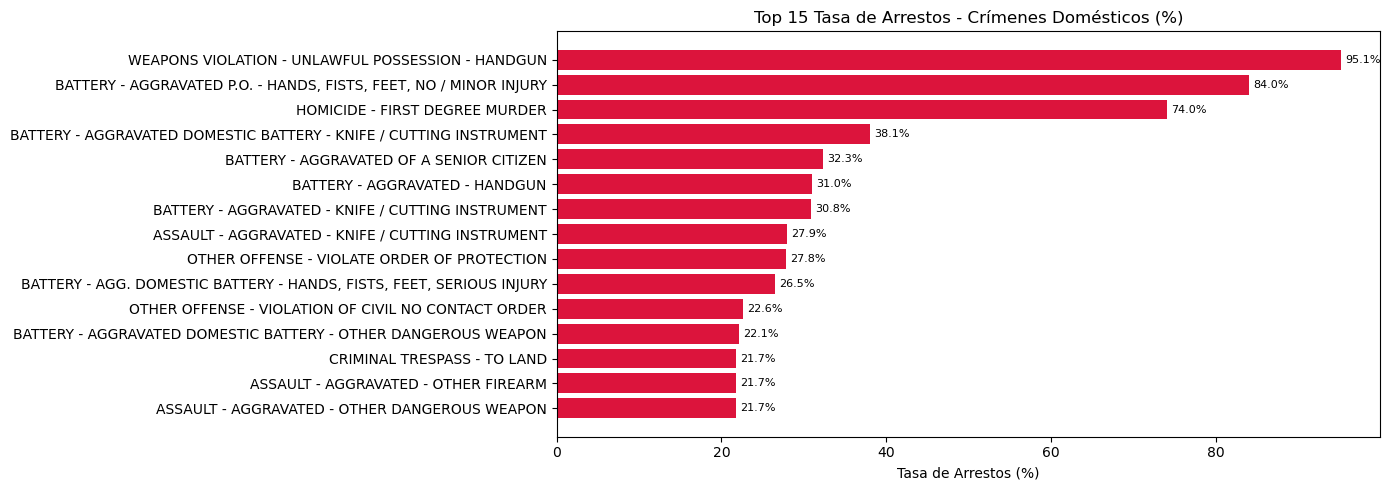

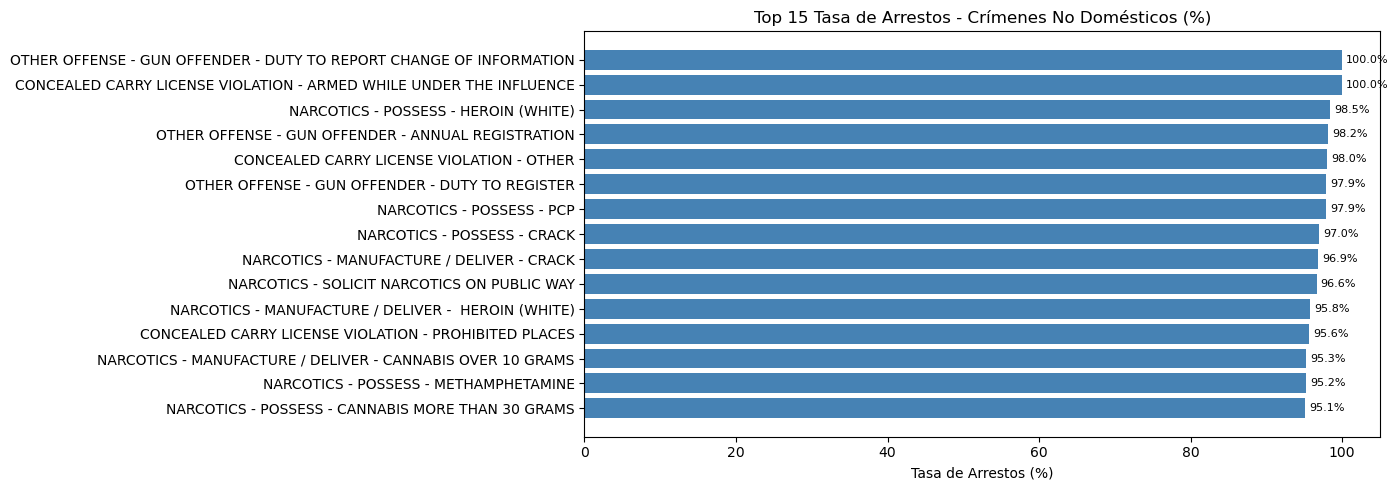

In [22]:
# Tasa de arrestos por tipo de crimen: Doméstico vs No Doméstico
for domestico, titulo, color in [(True, 'Crímenes Domésticos', 'crimson'), (False, 'Crímenes No Domésticos', 'steelblue')]:
    subset = df_chicago[df_chicago['Domestic'] == domestico]
    iucr_total_d = subset.groupby('IUCR').size()
    iucr_arrestos_d = subset[subset['Arrest'] == True].groupby('IUCR').size()
    tasa_d = (iucr_arrestos_d / iucr_total_d * 100).dropna()
    
    # Filtrar IUCR con al menos 30 casos
    sig = iucr_total_d[iucr_total_d >= 30].index
    tasa_d = tasa_d[tasa_d.index.isin(sig)].sort_values(ascending=False).head(15)
    
    etiquetas = []
    for iucr in tasa_d.index:
        row = subset[subset['IUCR'] == iucr].iloc[0]
        etiquetas.append(f"{row['IUCR Primary']} - {row['IUCR Secondary']}")
    
    plt.figure(figsize=(14, 5))
    bars = plt.barh(etiquetas[::-1], tasa_d.values[::-1], color=color)
    plt.title(f'Top 15 Tasa de Arrestos - {titulo} (%)')
    plt.xlabel('Tasa de Arrestos (%)')
    
    for bar in bars:
        width = bar.get_width()
        plt.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height()/2),
                    xytext=(3, 0), textcoords="offset points", ha='left', va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()

#### Análisis por Community Area
Se determina el crimen prevalente en cada Community Area y se identifican las zonas con mayor cantidad de delitos registrados.

In [23]:
# Análisis del crimen que prevalece por Community Area
conteo = df_chicago.groupby(['Community Area', 'Primary Type']).size().reset_index(name='Cantidad')
crimen_prevalente = conteo.loc[conteo.groupby('Community Area')['Cantidad'].idxmax()]
crimen_prevalente = crimen_prevalente.rename(columns={'Primary Type': 'Crimen Prevalente'})

# Agregar nombre del Community Area
crimen_prevalente = crimen_prevalente.merge(
    df_chicago[['Community Area', 'Community Area Description']].drop_duplicates(),
    on='Community Area', how='left'
)
crimen_prevalente = crimen_prevalente.sort_values('Cantidad', ascending=False)
crimen_prevalente

,Community Area,Crimen Prevalente,Cantidad,Community Area Description
7,8.0,THEFT,4627,NEAR NORTH SIDE
31,32.0,THEFT,3335,LOOP
27,28.0,THEFT,3044,NEAR WEST SIDE
24,25.0,BATTERY,2617,AUSTIN
5,6.0,THEFT,2451,LAKE VIEW
...,...,...,...,...
36,37.0,BATTERY,133,FULLER PARK
73,74.0,THEFT,105,MOUNT GREENWOOD
11,12.0,THEFT,92,FOREST GLEN
46,47.0,BATTERY,50,BURNSIDE


Top 10 Community Areas con mayor cantidad de crímenes:
  AUSTIN (Area 25): 11,765 crímenes
  NEAR NORTH SIDE (Area 8): 11,114 crímenes
  NEAR WEST SIDE (Area 28): 10,294 crímenes
  LOOP (Area 32): 8,564 crímenes
  SOUTH SHORE (Area 43): 8,089 crímenes
  WEST TOWN (Area 24): 6,855 crímenes
  NORTH LAWNDALE (Area 29): 6,402 crímenes
  HUMBOLDT PARK (Area 23): 6,143 crímenes
  AUBURN GRESHAM (Area 71): 6,094 crímenes
  GREATER GRAND CROSSING (Area 69): 6,087 crímenes


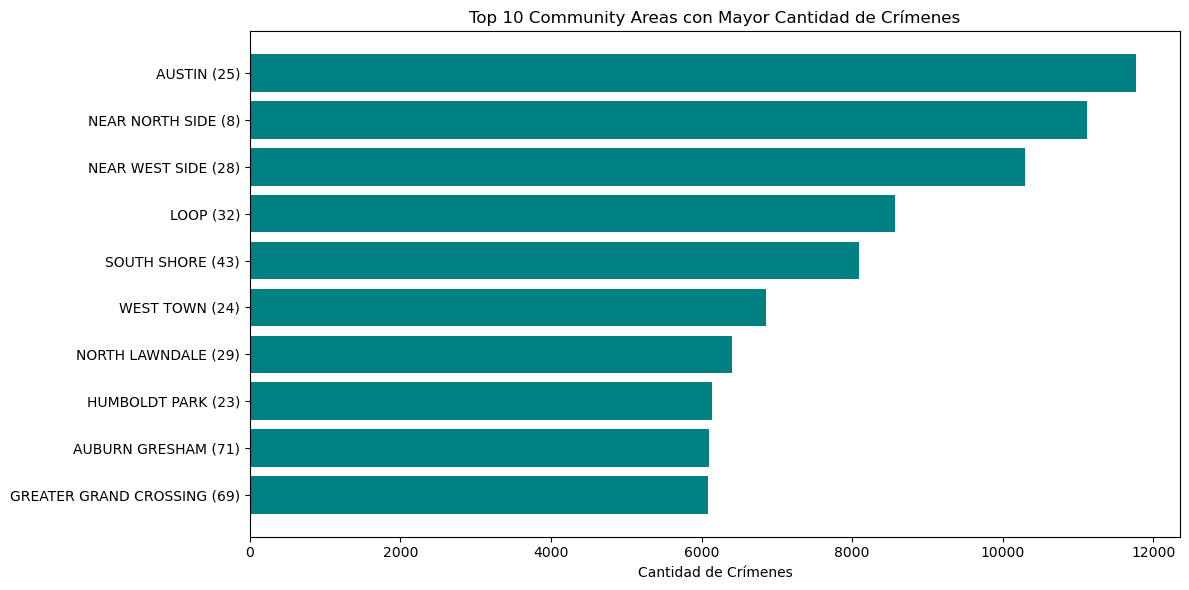

In [24]:
# Top 10 Community Areas con mayor cantidad de crímenes
top_areas = df_chicago.groupby('Community Area').agg(
    Cantidad=('Community Area', 'size'),
    Nombre=('Community Area Description', 'first')
).sort_values('Cantidad', ascending=False).head(10)

print("Top 10 Community Areas con mayor cantidad de crímenes:")
for area, row in top_areas.iterrows():
    print(f"  {row['Nombre']} (Area {int(area)}): {row['Cantidad']:,} crímenes")

plt.figure(figsize=(12, 6))
labels = [f"{row['Nombre']} ({int(area)})" for area, row in top_areas.iterrows()]
plt.barh(labels[::-1], top_areas['Cantidad'].values[::-1], color='teal')
plt.title('Top 10 Community Areas con Mayor Cantidad de Crímenes')
plt.xlabel('Cantidad de Crímenes')
plt.tight_layout()
plt.show()

#### Patrones temporales
Se analiza la distribución de crímenes por día de la semana, hora del día y mes para identificar patrones estacionales y franjas horarias de mayor incidencia.

C:\Users\aye_c\AppData\Local\Temp\ipykernel_18980\1621249372.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_chicago['Date'] = pd.to_datetime(df_chicago['Date'])


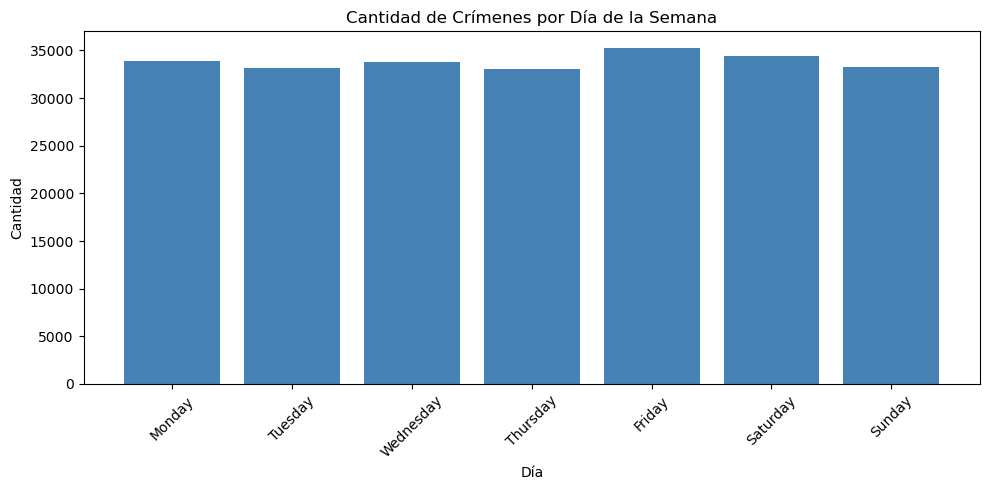

In [25]:
# Distribución de crímenes por día de la semana
df_chicago['Date'] = pd.to_datetime(df_chicago['Date'])
df_chicago['DayOfWeek'] = df_chicago['Date'].dt.day_name()

dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
casos_por_dia = df_chicago['DayOfWeek'].value_counts().reindex(dias_orden)

plt.figure(figsize=(10, 5))
plt.bar(casos_por_dia.index, casos_por_dia.values, color='steelblue')
plt.title('Cantidad de Crímenes por Día de la Semana')
plt.xlabel('Día')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

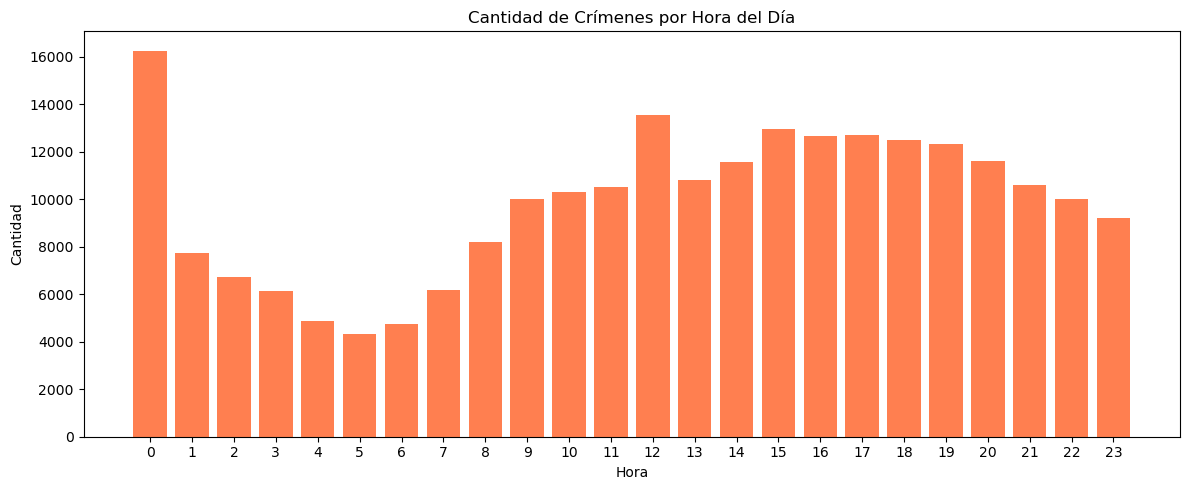

In [26]:
# Distribución de crímenes por hora del día
df_chicago['Hour'] = df_chicago['Date'].dt.hour

casos_por_hora = df_chicago['Hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(casos_por_hora.index, casos_por_hora.values, color='coral')
plt.title('Cantidad de Crímenes por Hora del Día')
plt.xlabel('Hora')
plt.ylabel('Cantidad')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

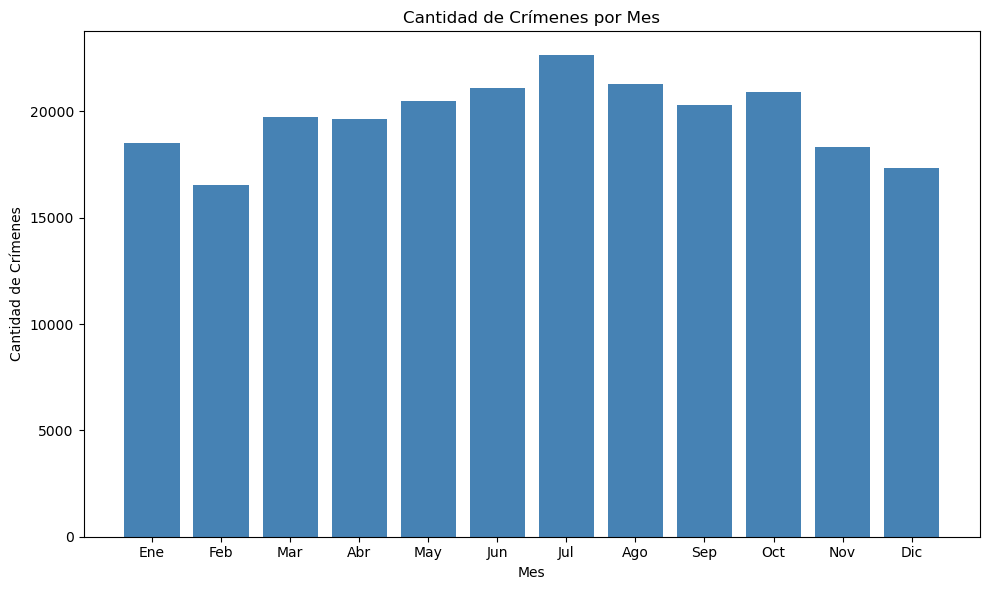

In [27]:
# Histograma de casos por mes
df_chicago['Date'] = pd.to_datetime(df_chicago['Date'])
df_chicago['Month'] = df_chicago['Date'].dt.month

casos_por_mes = df_chicago['Month'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(casos_por_mes.index, casos_por_mes.values, color='steelblue')
plt.title('Cantidad de Crímenes por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Crímenes')
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.tight_layout()
plt.show()

Evolución de casos domésitcos por mes

In [47]:
df_dom = df_chicago[df["Domestic"] == True].copy()
df_dom["Date"] = pd.to_datetime(df_dom["Date"])

df_dom["mes"] = df_dom["Date"].dt.to_period("M")

df_mes = df_dom.groupby("mes").size().reset_index(name="cantidad")
df_mes = df_mes.sort_values("mes")

# convertir a timestamp para graficar bien
df_mes["mes"] = df_mes["mes"].dt.to_timestamp()

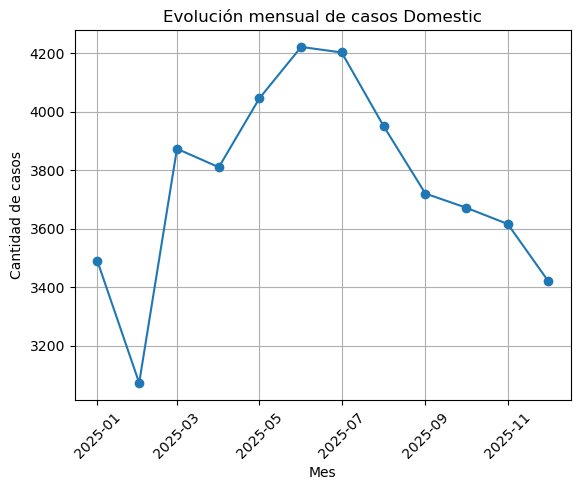

In [48]:
plt.figure()
plt.plot(df_mes["mes"], df_mes["cantidad"], marker="o")

plt.xlabel("Mes")
plt.ylabel("Cantidad de casos")
plt.title("Evolución mensual de casos Domestic")

plt.xticks(rotation=45)
plt.grid()

plt.show()

Evolución de arrestos por mes

In [50]:
df_Arrest = df_chicago[df_chicago["Arrest"] == True].copy()
df_Arrest["Date"] = pd.to_datetime(df_Arrest["Date"])

df_Arrest["mes"] = df_Arrest["Date"].dt.to_period("M")

df_mes = df_Arrest.groupby("mes").size().reset_index(name="cantidad")
df_mes = df_mes.sort_values("mes")

# convertir a timestamp para graficar bien
df_mes["mes"] = df_mes["mes"].dt.to_timestamp()

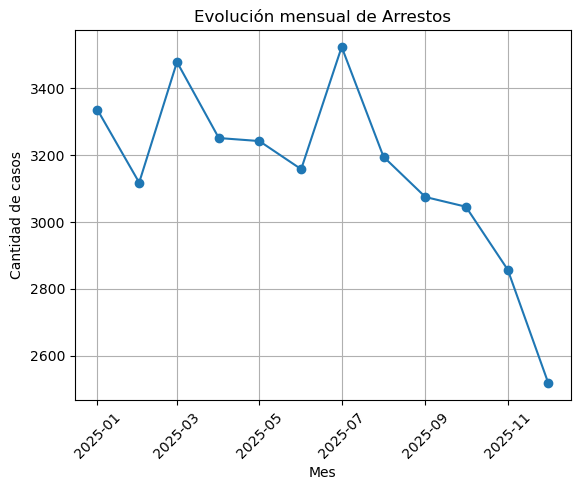

In [51]:
plt.figure()
plt.plot(df_mes["mes"], df_mes["cantidad"], marker="o")

plt.xlabel("Mes")
plt.ylabel("Cantidad de casos")
plt.title("Evolución mensual de Arrestos")

plt.xticks(rotation=45)
plt.grid()

plt.show()

#### Distribución por tipo de ubicación y correlaciones
Se identifican los lugares más frecuentes donde ocurren crímenes y se analiza la correlación entre las variables numéricas del dataset.

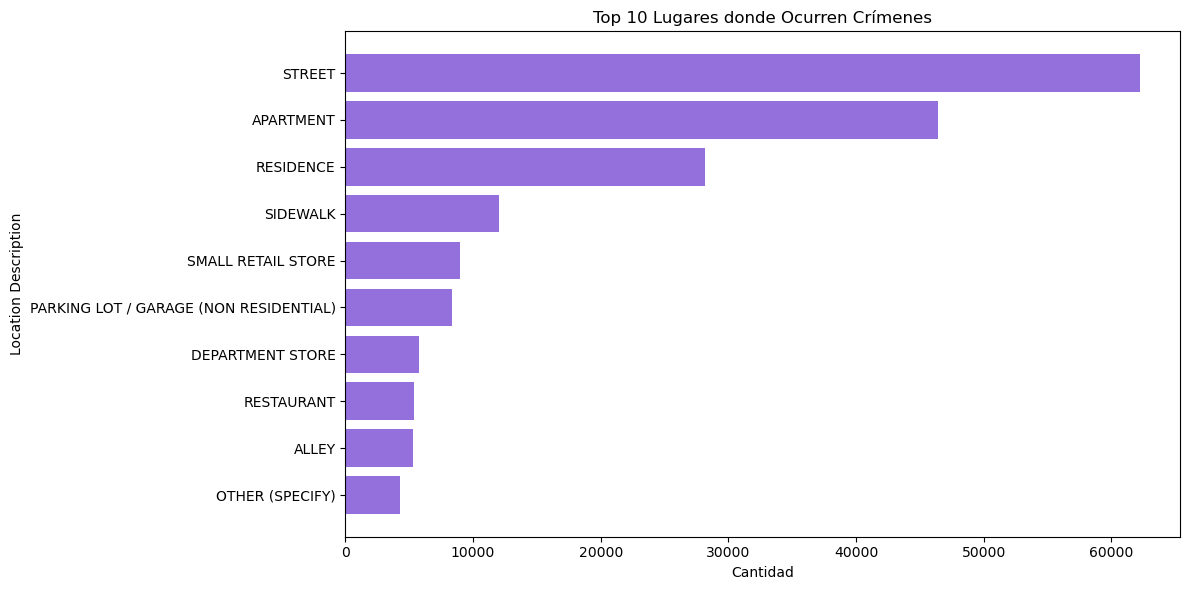

In [28]:
# Top 10 Location Description (lugares donde más ocurren crímenes)
top_locations = df_chicago['Location Description'].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_locations.index[::-1], top_locations.values[::-1], color='mediumpurple')
plt.title('Top 10 Lugares donde Ocurren Crímenes')
plt.xlabel('Cantidad')
plt.ylabel('Location Description')
plt.tight_layout()
plt.show()

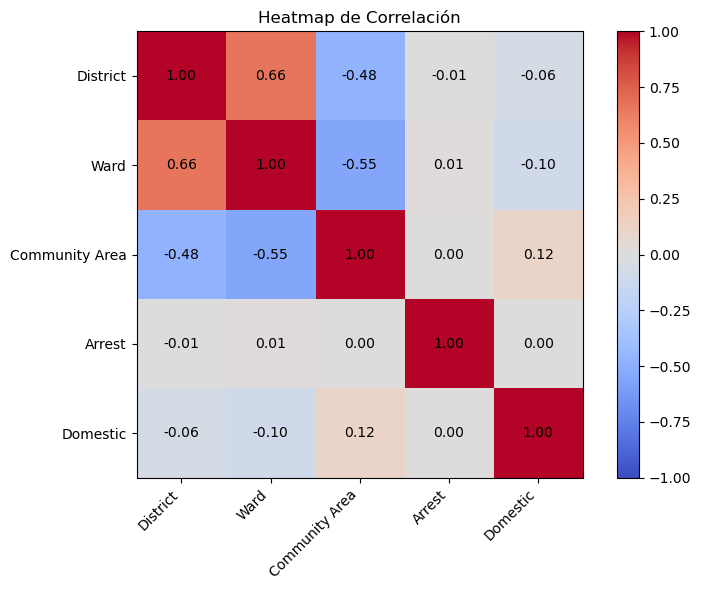

In [29]:
# Heatmap de correlación entre variables numéricas
cols_numericas = ['District', 'Ward', 'Community Area', 'Arrest', 'Domestic']
df_corr = df_chicago[cols_numericas].copy()
df_corr['Arrest'] = df_corr['Arrest'].astype(int)
df_corr['Domestic'] = df_corr['Domestic'].astype(int)

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=10)

plt.colorbar(im)
plt.title('Heatmap de Correlación')
plt.tight_layout()
plt.show()

Observaciones del heatmap:
- District y Ward tienen correlación positiva alta (0.66): es esperable ya que ambas son
  divisiones geográficas que se superponen en la ciudad.
- Community Area tiene correlación negativa con District (-0.48) y Ward (-0.55): esto refleja
  que la numeración de estas divisiones geográficas sigue un orden inverso, no una relación causal.
- Arrest y Domestic no muestran correlación (0.00): la probabilidad de arresto no varía
  significativamente entre crímenes domésticos y no domésticos.
- Arrest no correlaciona con ninguna variable geográfica (~0.00): la tasa de arrestos se
  distribuye de forma uniforme en toda la ciudad, sin concentrarse en zonas específicas.
- Domestic tiene correlación muy baja con Community Area (0.12): los crímenes domésticos
  se distribuyen de forma relativamente homogénea entre las áreas.

Nota: District, Ward y Community Area son identificadores geográficos, no variables ordinales.
Las correlaciones entre ellas reflejan coincidencias en la codificación numérica, no relaciones causales.

### Identificar errores, outliers (anomalías), valores faltantes y su tipo (MCAR, MAR, MNAR).

#### Valores nulos
Se analiza la proporción de valores faltantes en cada columna del dataset, identificando features con alto porcentaje de nulos y los registros afectados.

In [30]:
# Contar la proporción de valores nulos en cada columna
df_chicago.isna().sum()  

ID                                0
Case Number                       0
Date                              0
Block                             0
IUCR                              0
Primary Type                      0
Description                       0
Location Description           1097
Arrest                            0
Domestic                          0
Beat                              0
District                          0
Ward                              1
Community Area                    3
FBI Code                          0
X Coordinate                     91
Y Coordinate                     91
Year                              0
Updated On                        0
Latitude                         91
Longitude                        91
Location                         91
IUCR Primary                  10397
IUCR Secondary                10397
Index Code                    10397
Community Area Description        3
DayOfWeek                         0
Hour                        

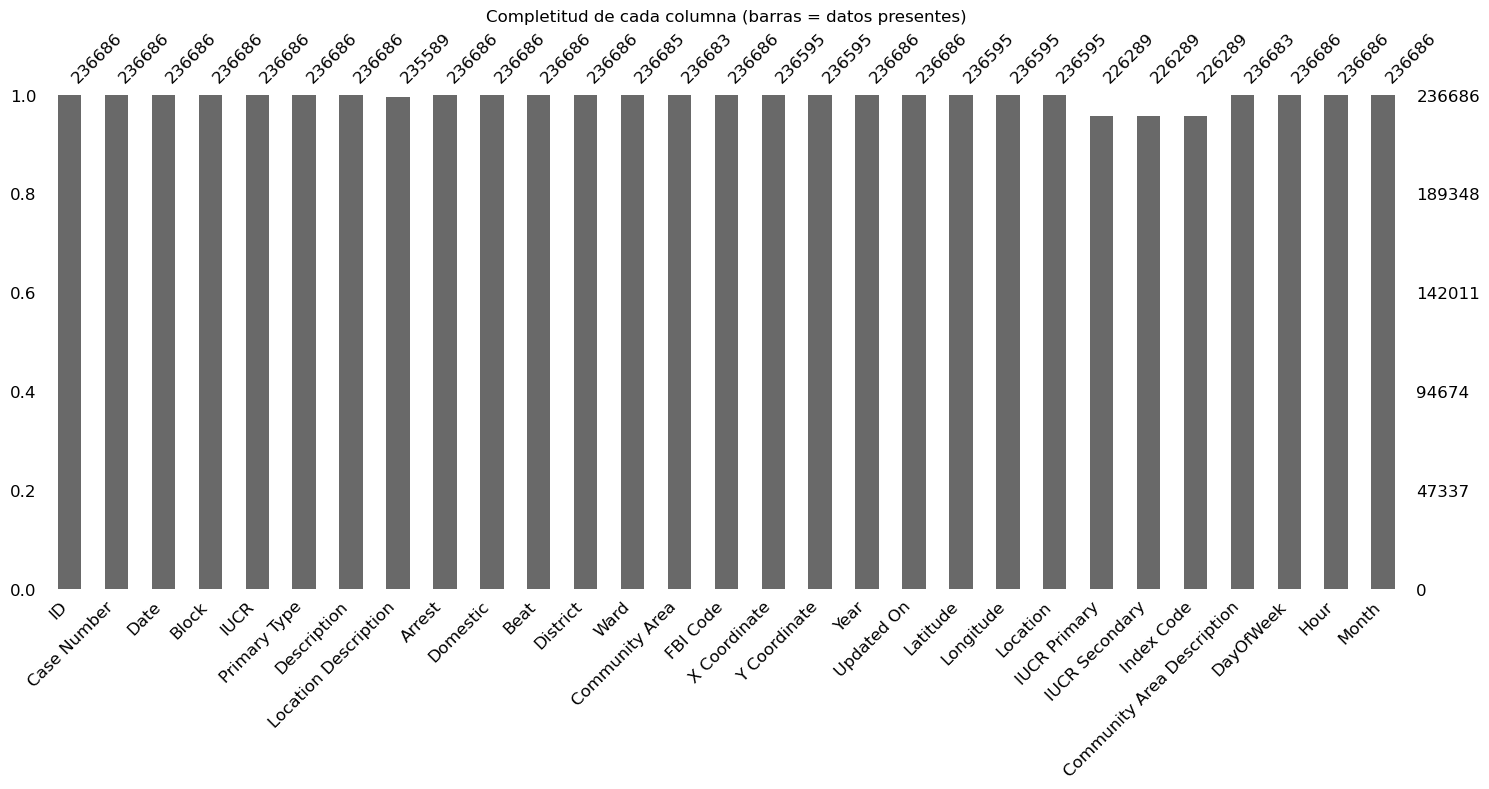

In [31]:
# Visualización de valores faltantes con missingno
fig, ax = plt.subplots(figsize=(15, 8))
msno.bar(df_chicago, fontsize=12, ax=ax)
plt.title('Completitud de cada columna (barras = datos presentes)')
plt.tight_layout()
plt.show()

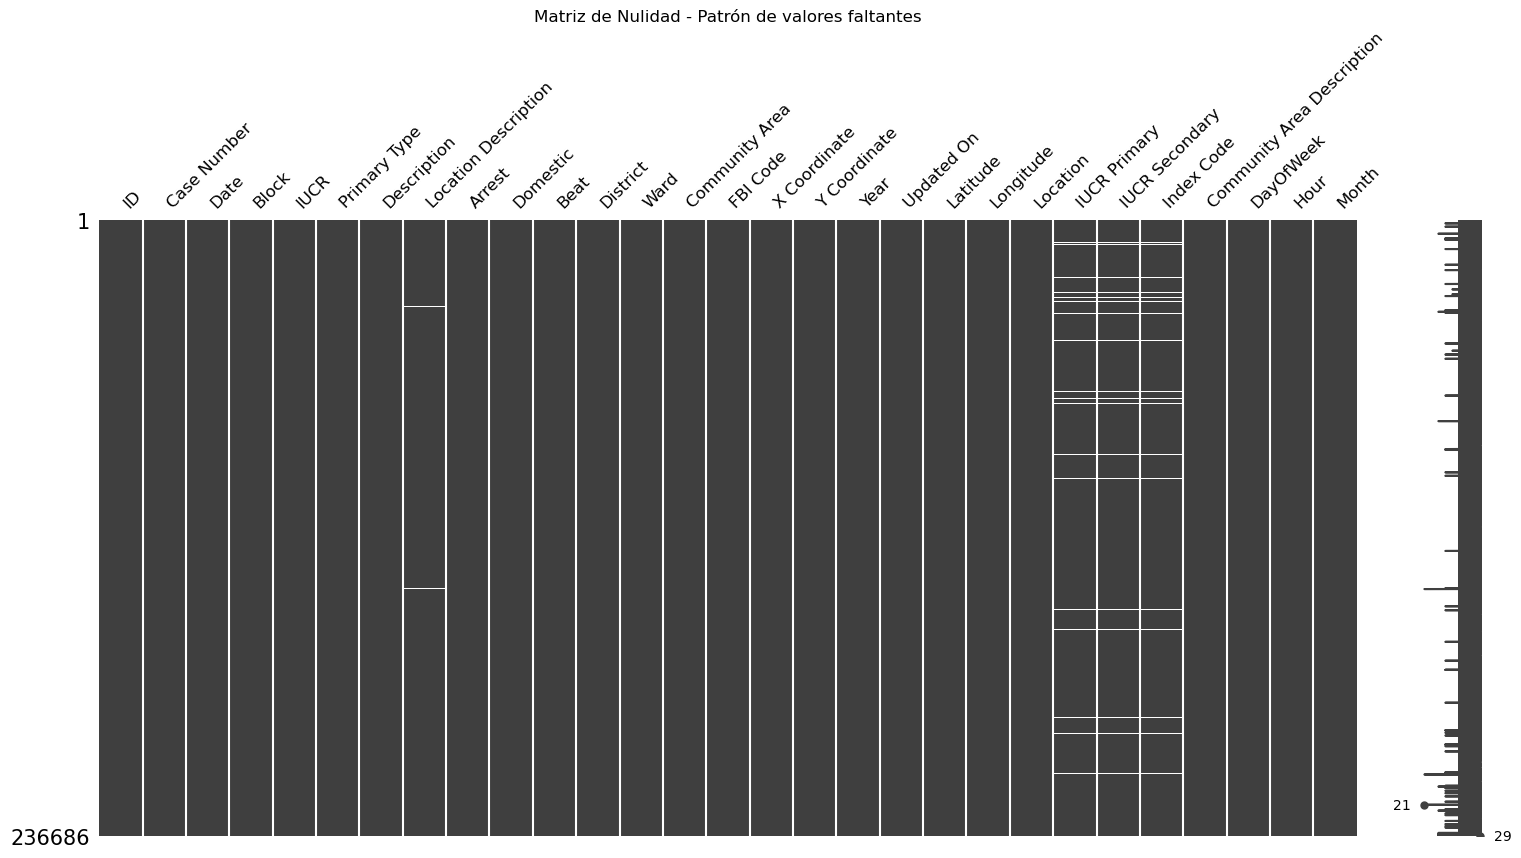

In [32]:
# Matriz de nulidad: patrón de valores faltantes (blanco = NaN)
msno.matrix(df_chicago, figsize=(18, 8), fontsize=12)
plt.title('Matriz de Nulidad - Patrón de valores faltantes')
plt.show()

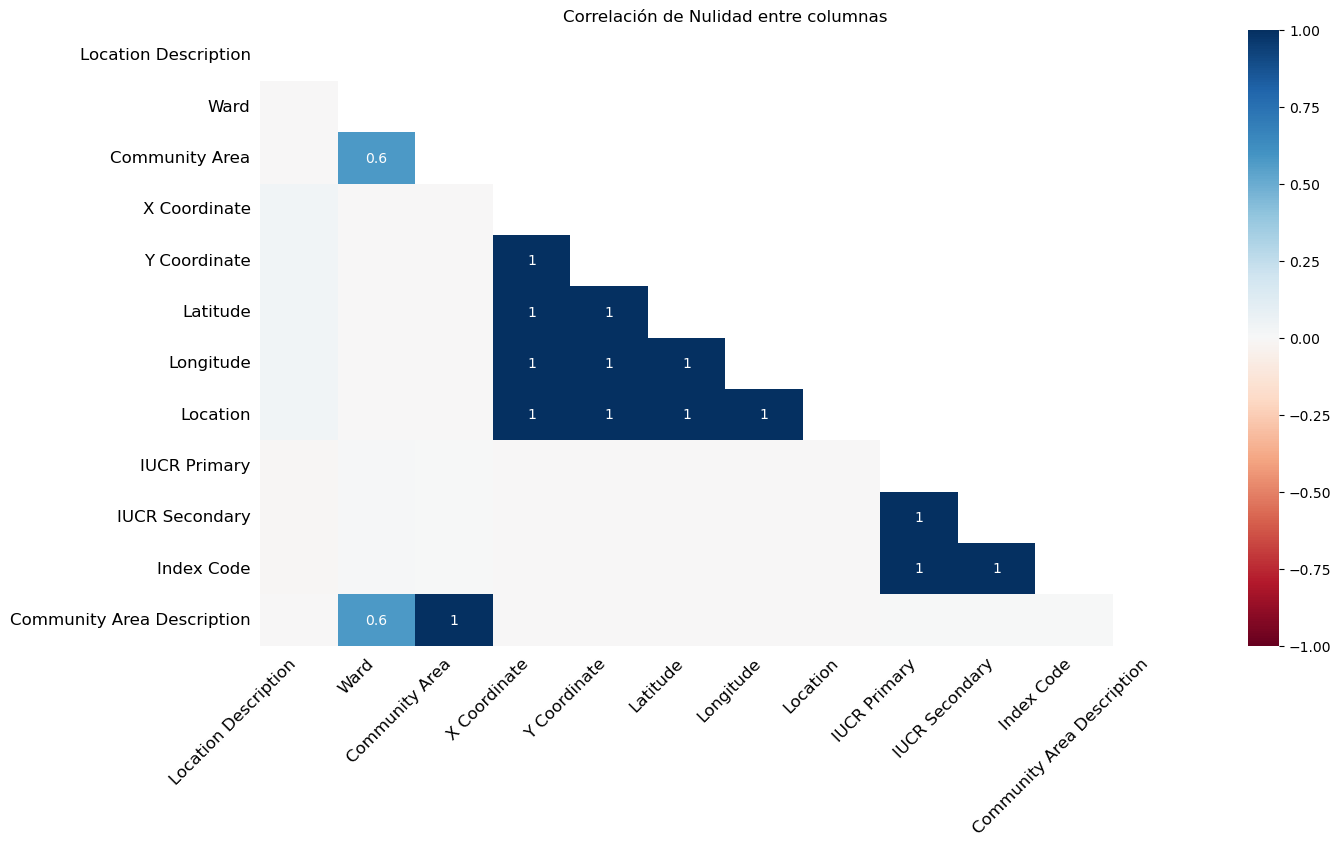

In [33]:
# Heatmap de correlación de nulidad: si los NaN de una columna se asocian con los de otra
msno.heatmap(df_chicago, fontsize=12, figsize=(15, 8))
plt.title('Correlación de Nulidad entre columnas')
plt.show()

In [34]:
# Features con más del 40% de valores nulos
total_rows = len(df_chicago)
null_percentages = (df_chicago.isna().sum() / total_rows * 100).round(2)
features_high_null = null_percentages[null_percentages > 40].sort_values(ascending=False)
print(f"Features con más del 40% de valores nulos ({len(features_high_null)} features):")
print(features_high_null.to_string())

Features con más del 40% de valores nulos (0 features):
Series([], )


In [35]:
# Registros con valores nulos en coordenadas/ubicación
# Se puede obeservar que son delitos de robo de identidad menores a $300, robos sin armas en un bar, acoso por telefono, o robos menores en la calle.
# Ver si es MAR o MNAR
registros_sin_ubicacion = df_chicago[df_chicago['X Coordinate'].isna() | df_chicago['Y Coordinate'].isna() | 
                             df_chicago['Latitude'].isna() | df_chicago['Longitude'].isna() | 
                             df_chicago['Location'].isna()]
print(f"Total de registros con valores nulos en coordenadas: {len(registros_sin_ubicacion)}")
registros_sin_ubicacion

Total de registros con valores nulos en coordenadas: 91


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Latitude,Longitude,Location,IUCR Primary,IUCR Secondary,Index Code,Community Area Description,DayOfWeek,Hour,Month
1294,14132925,JK176419,2025-12-29 12:00:00,005XX S DAMEN AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,APARTMENT,False,False,...,NaN,NaN,NaN,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,N,NEAR WEST SIDE,Monday,12,12
2572,14132705,JK176029,2025-12-26 22:30:00,014XX W DEVON AVE,0320,ROBBERY,STRONG ARM - NO WEAPON,BAR OR TAVERN,False,False,...,NaN,NaN,NaN,ROBBERY,STRONG ARM - NO WEAPON,I,ROGERS PARK,Friday,22,12
5280,14132132,JK174831,2025-12-22 11:00:00,071XX S FRANCISCO AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,NaN,NaN,NaN,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,N,CHICAGO LAWN,Monday,11,12
7045,14131862,JK175062,2025-12-19 14:37:00,081XX S BLACKSTONE AVE,1195,DECEPTIVE PRACTICE,FINANCIAL EXPLOITATION OF AN ELDERLY OR DISABL...,BANK,False,False,...,NaN,NaN,NaN,DECEPTIVE PRACTICE,FINANCIAL EXPLOITATION OF AN ELDERLY OR DISABL...,N,AVALON PARK,Friday,14,12
7196,14133030,JK176578,2025-12-19 09:00:00,035XX W ARMITAGE AVE,0930,MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,STREET,False,False,...,NaN,NaN,NaN,MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,I,LOGAN SQUARE,Friday,9,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236629,14087806,JK121157,2025-01-01 00:00:00,030XX W 19TH ST,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,OTHER (SPECIFY),False,True,...,NaN,NaN,NaN,OTHER OFFENSE,HARASSMENT BY TELEPHONE,N,SOUTH LAWNDALE,Wednesday,0,1
236630,14108774,JK147149,2025-01-01 00:00:00,030XX W ARMITAGE AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,OTHER (SPECIFY),False,False,...,NaN,NaN,NaN,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,N,LOGAN SQUARE,Wednesday,0,1
236631,14094402,JK129563,2025-01-01 00:00:00,025XX W FULLERTON AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,RESIDENCE,False,False,...,NaN,NaN,NaN,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,N,LOGAN SQUARE,Wednesday,0,1
236633,14105893,JK143522,2025-01-01 00:00:00,0000X E 74TH ST,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,OTHER (SPECIFY),False,False,...,NaN,NaN,NaN,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,N,GREATER GRAND CROSSING,Wednesday,0,1


#### Clasificación de valores faltantes (MCAR, MAR, MNAR)

- **MCAR (Missing Completely At Random)**: la probabilidad de que un dato falte no depende de ninguna variable. El porcentaje de nulos es similar en todos los grupos.
- **MAR (Missing At Random)**: la probabilidad de que un dato falte depende de otra variable observada. El porcentaje de nulos varía según el grupo.
- **MNAR (Missing Not At Random)**: la probabilidad de que un dato falte depende del propio valor faltante. No se puede verificar directamente con los datos.

Para clasificar, se analiza si el porcentaje de nulos en las columnas con más faltantes varía según variables como Primary Type, District o Arrest.


Interpretación:
- Si el % de nulos varía significativamente entre grupos -> MAR (depende de otra variable)
- Si el % de nulos es similar en todos los grupos -> MCAR (aleatorio)

In [36]:
# Análisis MCAR/MAR: porcentaje de nulos en Latitude por grupo
def nulos_por_grupo(df, grupo_col, target_col):
    return (
        df.groupby(grupo_col, observed=True)[target_col]
        .apply(lambda x: x.isnull().mean() * 100)
        .reset_index(name=f'% Nulos en {target_col}')
        .sort_values(f'% Nulos en {target_col}', ascending=False)
    )

In [37]:
# Nulos en Latitude por Primary Type
nulos_lat_tipo = nulos_por_grupo(df_chicago, 'Primary Type', 'Latitude')
print("% de nulos en Latitude por Primary Type (top 10):")
print(nulos_lat_tipo.head(10).to_string(index=False))

% de nulos en Latitude por Primary Type (top 10):
              Primary Type  % Nulos en Latitude
        DECEPTIVE PRACTICE             0.352065
               SEX OFFENSE             0.229008
                  STALKING             0.174825
OFFENSE INVOLVING CHILDREN             0.129618
   CRIMINAL SEXUAL ASSAULT             0.059809
             OTHER OFFENSE             0.059719
                     THEFT             0.019983
                   ROBBERY             0.017185
                   BATTERY             0.011753
           CRIMINAL DAMAGE             0.011447


In [38]:
# Nulos en Latitude por District
nulos_lat_distrito = nulos_por_grupo(df_chicago, 'District', 'Latitude')
print("% de nulos en Latitude por District:")
print(nulos_lat_distrito.to_string(index=False))

% de nulos en Latitude por District:
 District  % Nulos en Latitude
       19             0.079968
       22             0.078782
       25             0.078003
       17             0.068568
       14             0.062367
       20             0.060181
        2             0.055175
       18             0.053062
       24             0.052666
       11             0.038682
       16             0.037161
        5             0.032352
        4             0.030611
        9             0.028667
        8             0.026314
       15             0.025598
        3             0.023605
       10             0.021059
        1             0.014628
       12             0.013436
        7             0.009894
        6             0.007375
       31             0.000000


In [39]:
# Nulos en Latitude por Arrest
nulos_lat_arresto = nulos_por_grupo(df_chicago, 'Arrest', 'Latitude')
print("% de nulos en Latitude por Arrest:")
print(nulos_lat_arresto.to_string(index=False))

% de nulos en Latitude por Arrest:
 Arrest  % Nulos en Latitude
  False             0.045249
   True             0.002646


In [40]:
# Nulos en Latitude por Domestic
nulos_lat_domestic = nulos_por_grupo(df_chicago, 'Domestic', 'Latitude')
print("% de nulos en Latitude por Domestic:")
print(nulos_lat_domestic.to_string(index=False))

% de nulos en Latitude por Domestic:
 Domestic  % Nulos en Latitude
    False             0.039668
     True             0.033264


#### Detección de Outliers
Se utilizan el método IQR para detectar valores atípicos en las variables numéricas:
- **Método IQR (Rango Intercuartílico)**: un valor es outlier si cae por debajo de Q1 - 1.5*IQR o por encima de Q3 + 1.5*IQR.

In [41]:
# Detección de outliers con método IQR en variables numéricas
vars_outliers = ['District', 'Ward', 'Community Area', 'Beat']
df_num = df_chicago[vars_outliers].dropna()

Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = (df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR))

print("Outliers detectados por método IQR:")
for col in vars_outliers:
    n_outliers = outliers_iqr[col].sum()
    pct = n_outliers / len(df_num) * 100
    print(f"  {col}: {n_outliers:,} outliers ({pct:.2f}%)")

Outliers detectados por método IQR:
  District: 0 outliers (0.00%)
  Ward: 0 outliers (0.00%)
  Community Area: 0 outliers (0.00%)
  Beat: 0 outliers (0.00%)


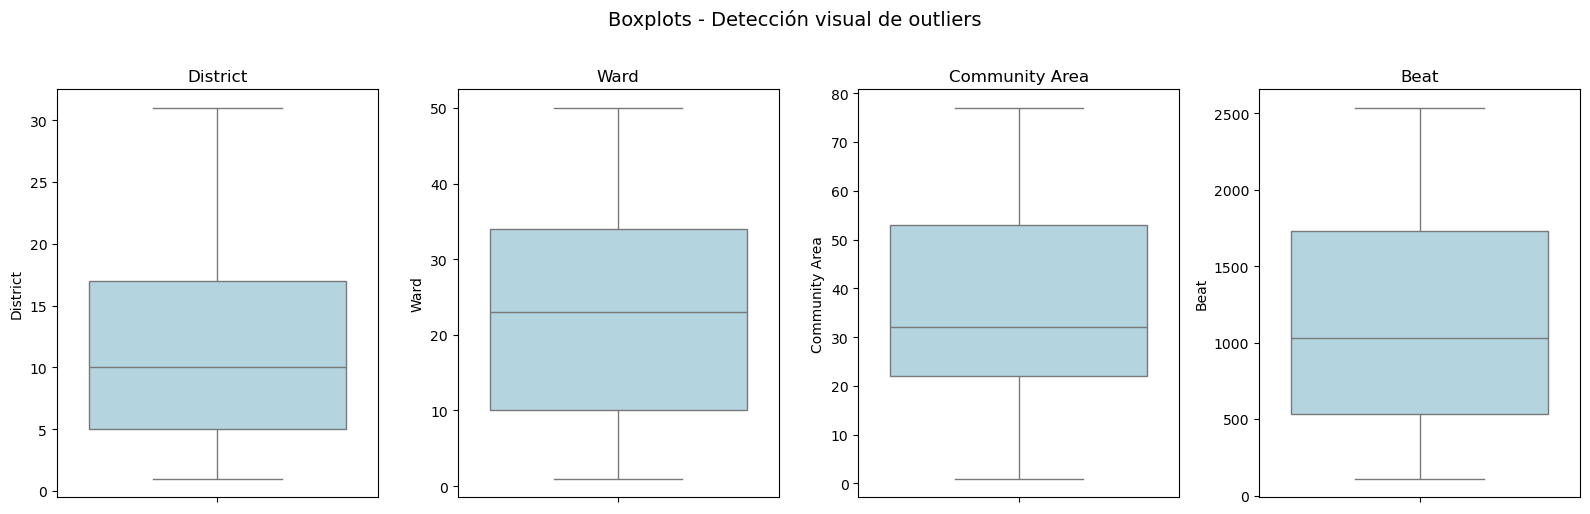

In [42]:
# Boxplots para visualizar outliers
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, vars_outliers):
    sns.boxplot(y=df_chicago[col], ax=ax, color='lightblue')
    ax.set_title(f'{col}')

plt.suptitle('Boxplots - Detección visual de outliers', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Aplicación de técnicas de visualización

Se utilizan técnicas de visualización para ilustrar la distribución geográfica de los crímenes, complementando los gráficos de barras, histogramas y heatmaps presentados en las secciones anteriores.

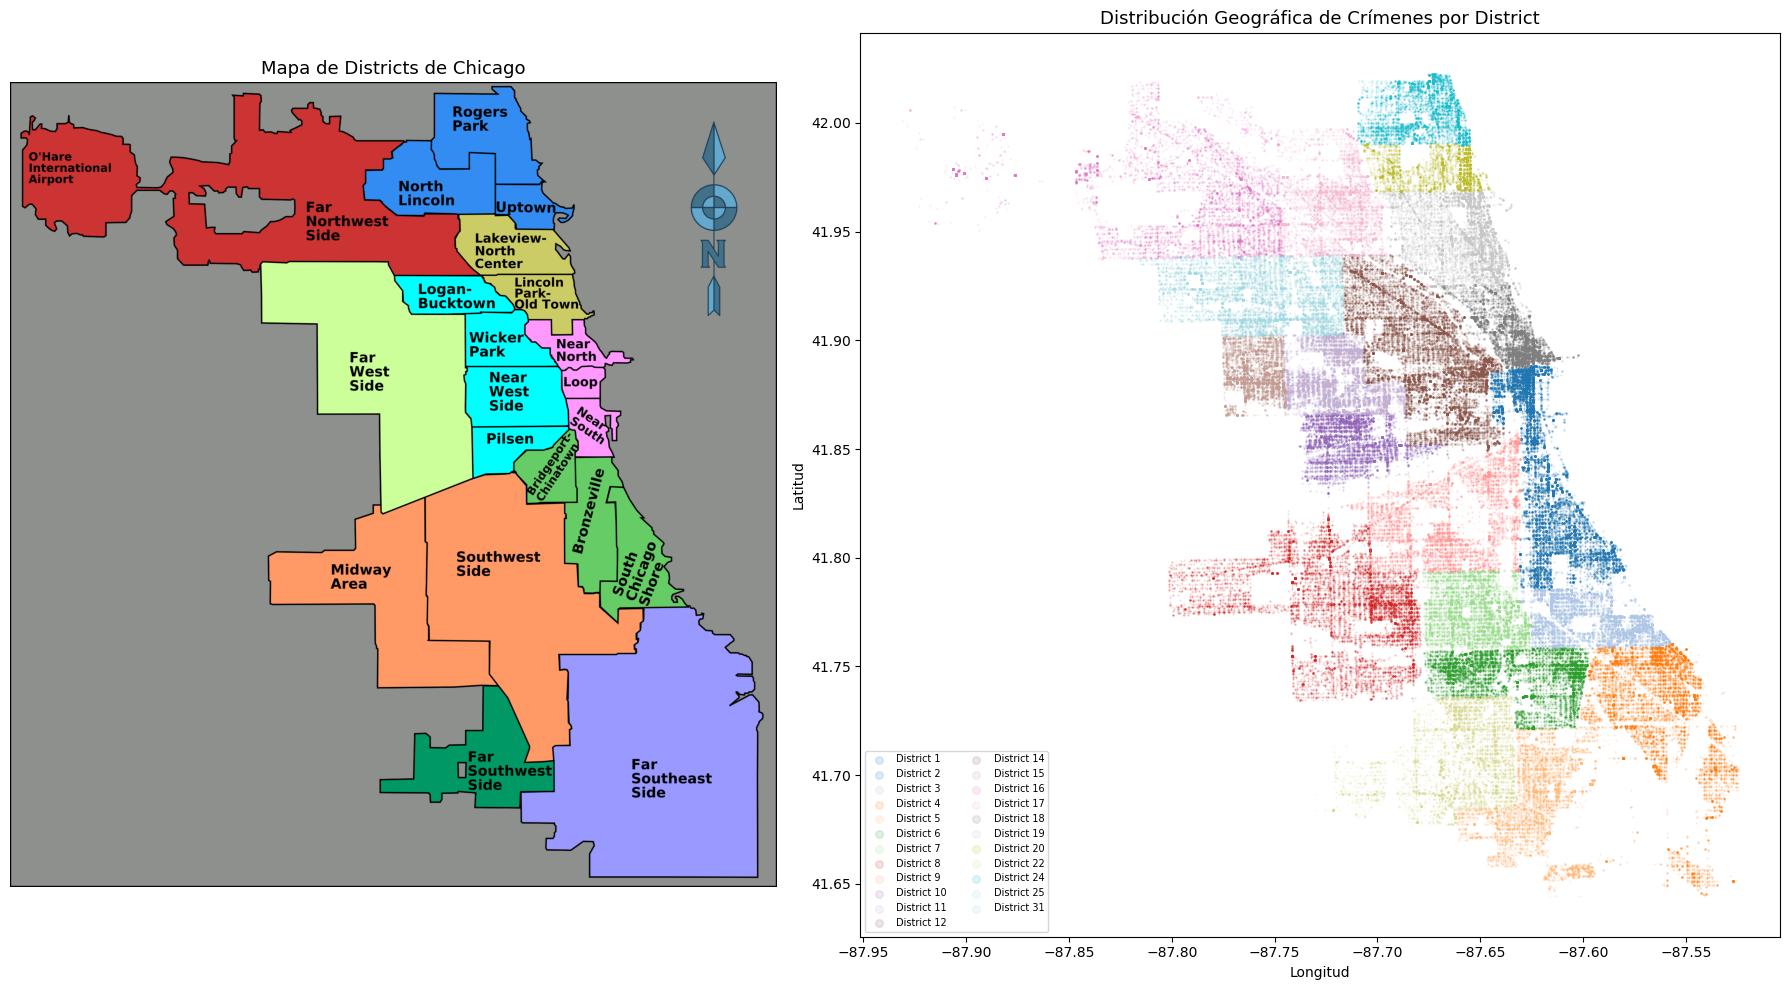

In [43]:
# Distribución geográfica de crímenes coloreado por District + mapa de referencia
df_geo = df_chicago.dropna(subset=['Latitude', 'Longitude', 'District'])

fig, axes = plt.subplots(1, 2, figsize=(18, 10), gridspec_kw={'width_ratios': [1, 1.2]})

# Panel izquierdo: mapa de referencia de districts
img = Image.open('Chicago_districts_map.png')
axes[0].imshow(img)
axes[0].set_title('Mapa de Districts de Chicago', fontsize=13)
axes[0].axis('off')

# Panel derecho: scatter plot de crímenes
districts = sorted(df_geo['District'].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(districts)))

for district, color in zip(districts, colors):
    subset = df_geo[df_geo['District'] == district]
    axes[1].scatter(subset['Longitude'], subset['Latitude'], s=0.3, alpha=0.15,
                    c=[color], label=f'District {int(district)}')

axes[1].set_title('Distribución Geográfica de Crímenes por District', fontsize=13)
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')
axes[1].legend(markerscale=10, fontsize=7, loc='lower left', ncol=2)

plt.tight_layout()
plt.show()

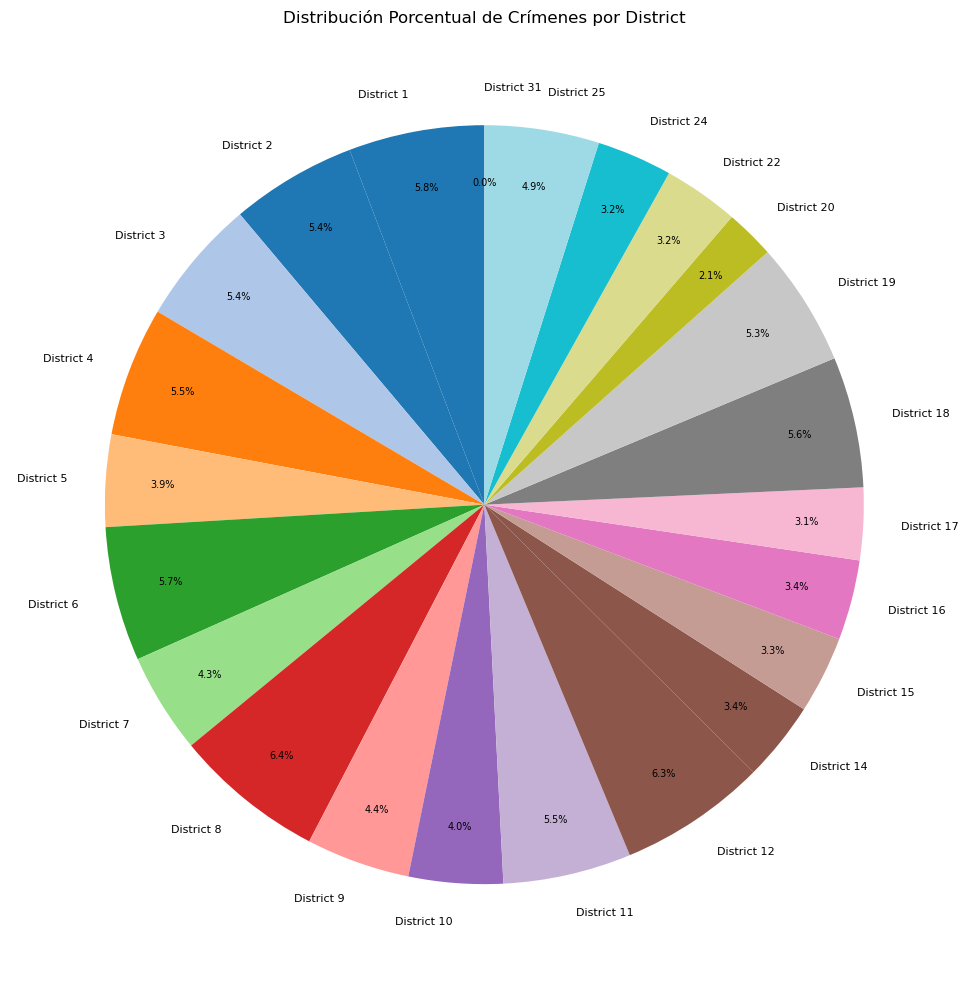

In [44]:
# Distribución porcentual de crímenes por District (pie chart)
district_counts = df_chicago['District'].value_counts().sort_index()

plt.figure(figsize=(10, 10))
labels = [f'District {int(d)}' for d in district_counts.index]
colors = plt.cm.tab20(np.linspace(0, 1, len(district_counts)))

wedges, texts, autotexts = plt.pie(
    district_counts.values, labels=labels, autopct='%1.1f%%',
    startangle=90, colors=colors, pctdistance=0.85,
    textprops={'fontsize': 8}
)
for autotext in autotexts:
    autotext.set_fontsize(7)

plt.title('Distribución Porcentual de Crímenes por District')
plt.tight_layout()
plt.show()

# Hallazgos del Dataset de Crímenes de Chicago 2025

In [45]:
# Resumen del análisis exploratorio
df_chicago['Date'] = pd.to_datetime(df_chicago['Date'])

print("=" * 65)
print("  RESUMEN DEL ANÁLISIS EXPLORATORIO")
print("  Dataset de Crímenes de Chicago 2025")
print("=" * 65)

print(f"\n  Total de registros: {len(df_chicago):,}")
print(f"  Rango temporal: {df_chicago['Date'].min().strftime('%Y-%m-%d')} a {df_chicago['Date'].max().strftime('%Y-%m-%d')}")

# Top crimen, district, community area, location, hora pico, día pico
top_crimen = df_chicago['Primary Type'].value_counts().index[0]
top_district = int(df_chicago['District'].value_counts().index[0])
top_community = df_chicago['Community Area Description'].value_counts().index[0]
top_location = df_chicago['Location Description'].value_counts().index[0]
hora_pico = int(df_chicago['Date'].dt.hour.value_counts().index[0])
dia_pico = df_chicago['Date'].dt.day_name().value_counts().index[0]
mes_pico = df_chicago['Date'].dt.month_name().value_counts().index[0]

print(f"\n  Delito más frecuente: {top_crimen}")
print(f"  District con más denuncias: {top_district}")
print(f"  Community Area con más denuncias: {top_community}")
print(f"  Lugar más frecuente: {top_location}")
print(f"  Hora pico de denuncias: {hora_pico}:00 hs")
print(f"  Día con más denuncias: {dia_pico}")
print(f"  Mes con más denuncias: {mes_pico}")

# Index Code
index_pct = df_chicago['Index Code'].value_counts(normalize=True) * 100
print(f"\n  Delitos graves (Index I): {index_pct.get('I', 0):.1f}%")
print(f"  Delitos menores (Non-Index N): {index_pct.get('N', 0):.1f}%")

# Arrestos
arrest_pct = df_chicago['Arrest'].value_counts(normalize=True) * 100
print(f"\n  Tasa de arrestos: {arrest_pct.get(True, 0):.1f}%")
print(f"  Crímenes domésticos: {df_chicago['Domestic'].value_counts(normalize=True).get(True, 0)*100:.1f}%")

# Valores nulos
null_pct = (df_chicago.isna().sum() / len(df_chicago) * 100)
high_null = null_pct[null_pct > 40]
print(f"\n  Features con >40% valores nulos: {len(high_null)}")
for col in high_null.index:
    print(f"    - {col}: {high_null[col]:.1f}%")

print("\n" + "=" * 65)

  RESUMEN DEL ANÁLISIS EXPLORATORIO
  Dataset de Crímenes de Chicago 2025

  Total de registros: 236,686
  Rango temporal: 2025-01-01 a 2025-12-31

  Delito más frecuente: THEFT
  District con más denuncias: 8
  Community Area con más denuncias: AUSTIN
  Lugar más frecuente: STREET
  Hora pico de denuncias: 0:00 hs
  Día con más denuncias: Friday
  Mes con más denuncias: July

  Delitos graves (Index I): 41.8%
  Delitos menores (Non-Index N): 58.2%

  Tasa de arrestos: 16.0%
  Crímenes domésticos: 19.1%

  Features con >40% valores nulos: 0



## Posibles problemas de ML supervisado

A partir del análisis exploratorio realizado, se identifican los siguientes problemas de Machine Learning supervisado que podrían abordarse con este dataset:

---

### Top 10 propuestas

| # | Problema | Tipo | Variable Target | Features principales |
|---|----------|------|----------------|---------------------|
| 1 | **Predicción de arresto** | Clasificación binaria | `Arrest` (True/False) | Primary Type, District, Community Area, Location Description, Domestic, hora, día, mes |
| 2 | **Predicción de crimen doméstico** | Clasificación binaria | `Domestic` (True/False) | Primary Type, IUCR, Location Description, District, hora, Arrest |
| 3 | **Clasificación del tipo de crimen** | Clasificación multiclase | `Primary Type` | District, Community Area, Location Description, hora, día, mes, Domestic, coordenadas |
| 4 | **Predicción de gravedad del delito** | Clasificación binaria | `Index Code` (I/N) | Primary Type, Location Description, District, hora, Domestic, Arrest |
| 5 | **Predicción de zona del crimen** | Clasificación multiclase | `District` | Primary Type, hora, día, Location Description, Domestic, Arrest |
| 6 | **Predicción de ubicación específica** | Clasificación multiclase | `Location Description` | Primary Type, District, Community Area, hora, Domestic |
| 7 | **Predicción de Community Area** | Clasificación multiclase | `Community Area` | Primary Type, hora, día, Location Description, Domestic |
| 8 | **Estimación del Beat policial** | Regresión | `Beat` | District, Community Area, Primary Type, hora, coordenadas |
| 9 | **Predicción de hora del crimen** | Regresión | `Hour` (0-23) | Primary Type, District, Location Description, Domestic, día de la semana |
| 10 | **Predicción del mes del crimen** | Regresión / Clasificación | `Month` (1-12) | Primary Type, District, Community Area, Location Description |

---

### Problema recomendado: Predicción de Arresto (Propuesta #1)

**Tipo:** Clasificación binaria

**Variable target:** `Arrest` (True / False)

**Justificación:**
- Es una variable binaria clara y bien definida
- Presenta un desbalance natural (~16% True vs ~84% False) que es un desafío interesante y realista
- Tiene aplicación práctica directa: predecir la probabilidad de que un crimen termine en arresto puede ayudar a la asignación de recursos policiales
- Las features disponibles (tipo de crimen, ubicación, hora, contexto doméstico) son intuitivas y explicables
- Permite explorar técnicas de manejo de clases desbalanceadas

**Features candidatas:**
- `Primary Type` / `IUCR` — tipo de delito
- `District`, `Community Area`, `Beat` — zona geográfica
- `Location Description` — tipo de lugar
- `Domestic` — contexto doméstico
- `Index Code` — gravedad del delito
- Hora, día de la semana, mes — componentes temporales extraídos de `Date`